In [10]:
pip install xgboost

  Using cached xgboost-3.1.3-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.1.3-py3-none-win_amd64.whl (72.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kstest, anderson


#Grab data and put numerical vals in one table
#################################################################################################################
dataset_as_given = pd.read_csv(r"d:\Desktop\Practice Python\21.gym_members_exercise_tracking.csv")
#print(dataset_as_given)

# Get column names
column_names = dataset_as_given.columns
#print(column_names)

desired = ["Age", "Weight (kg)", "Height (m)", "Max_BPM", "Avg_BPM", "Resting_BPM", 
           "Session_Duration (hours)", "Calories_Burned", "Fat_Percentage", "Water_Intake (liters)", "Workout_Frequency (days/week)", "Experience_Level", "BMI"]

dataset_as_given_numeric = dataset_as_given[desired]



#Get Rid of Outliers
#################################################################################################################

# Copy the dataset so you keep the original intact
cleaned_df = dataset_as_given.copy()

# Select numeric columns
numeric_cols = cleaned_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]



print("Original rows:", dataset_as_given.shape[0])
print("Cleaned rows:", cleaned_df.shape[0])
print("Rows removed:", dataset_as_given.shape[0] - cleaned_df.shape[0])


#################################################################################################################

encoded_df = cleaned_df.copy()

encoded_df['Gender'] = encoded_df['Gender'].map({
    'Male': 1,
    'Female': 0
})

workout_dummies = pd.get_dummies(encoded_df['Workout_Type'], prefix='Workout', drop_first=True)
encoded_df = pd.concat([encoded_df.drop(columns=['Workout_Type']), workout_dummies], axis=1)




Original rows: 973
Cleaned rows: 931
Rows removed: 42


In [2]:
# ============================================================
#   TRAIN/TEST SPLIT + SCALING
#   This prepares your data for any ML model
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Define X (features) and y (target)
# ------------------------------------------------------------
# Gender must already be encoded as 0/1 in encoded_df
X = encoded_df.drop(columns=['Gender'])
y = encoded_df['Gender']

# ------------------------------------------------------------
# 2. Train/Test Split
# ------------------------------------------------------------
# test_size=0.2 means 20% of data is held out for testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 3. Scale the numeric features
# ------------------------------------------------------------
# Scaling helps models like Logistic Regression, SVM, KNN, Neural Networks
# Tree-based models (Random Forest, XGBoost) do NOT require scaling,
# but scaling does not harm them.
scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 4. Optional: Print shapes to confirm everything looks right
# ------------------------------------------------------------
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nScaled versions created: X_train_scaled, X_test_scaled")


X_train shape: (744, 16)
X_test shape: (187, 16)
y_train shape: (744,)
y_test shape: (187,)

Scaled versions created: X_train_scaled, X_test_scaled


Decision Tree<br><br>

A Decision Tree helps us to make decisions by mapping out different choices and their possible outcomes. It is used in machine learning for tasks like classification and prediction. <br><br>

A Decision Tree helps us make decisions by showing different options and how they are related. It has a tree-like structure that starts with one main question called the root node which represents the entire dataset. From there, the tree branchesout into different possibilities based on features in the data.<br><br>

- Root Note -> Starting point representing the whole dataset<br>
- Bracnhes -> Lines connecting nodes showing the flow from one decision to another<br>
- Internal Nodes -> Points where decisions are made based on data features<br>
- Leaf Nodes -> End points of the tree where the final decision or prediction is made<br><br>

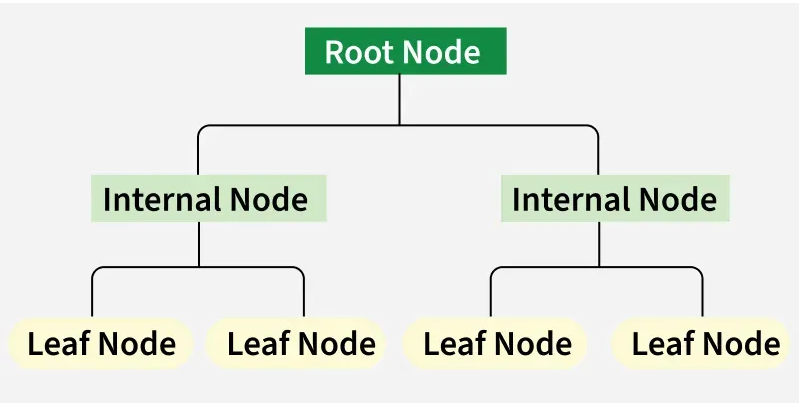<br><br>

A Decision Tree also helps with decision-making by showing possible outcomes clearly. By looking at the 'branches' we can quickly compare options and figure out the best choice.<br><br>

There are mainly two types of Decision Trees based o the target variable:<br><br>

1. Classification Trees -> Used for predicting categorical outcomes like spam or not spam. These trees split the data based on features to classify data into predefined categories.<br><br>

2. Regression Trees -> Used for predicting continous outcomes like predicting house prices. Instead of assigning categories, it provides numberical predictions based on the input features.<br><br>

How do Decision Trees Work?<br><br>

1. Start with the Root Node -> It bagins with a main questions at the root node which is derived from the dataset's features<br><br>

2. Ask Yes/No Questions -> From the root, the tree asks a series of yes/no questions to split the data into subsets based on specific attributes<br><br>

3. Branching Based on Answers -> Each question leads to different braches:<br>
- If the answer is 'YES', the tree follows one path<br>
- If the answer is 'NO', the tree follows another path<br><br>

4. Continue Splitting -> This branching continues through further decisions helps in reducing the data down step-by-step<br><br>

5. Reach the Leaf Node -> The process ends when there are no more useful questions to ask leading to the leaf node where the final decision or prediction is made<br><br>

Let us look at a simple example to see how it works. Imagine we need to decide whether to drink coffee based on the time of the day and how tired we feel. The tree first checks the time:<br><br>

1. In the Morning -> It asks 'Tired?'<br><br>

- If 'YES', the tree suggests drinking coffee<br>
- If 'NO', it says no coffee is needed<br><br>

2. In the afternoon -> It asks again 'Tired?'<br><br>

- If 'YES', it suggest drinking coffee<br>
- If 'NO', no coffee is needed<br><br>

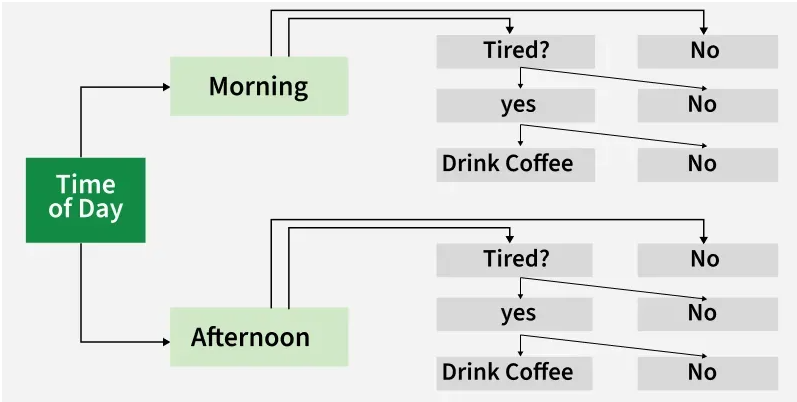<br><br>

Splitting Criteria in Decision Trees<br><br>

In a Decision Tree, the process of splitting data at each node is important. The splitting criteria finds the best feature to split the data on. Common splitting criteria include Gini Impurity and Entropy.<br><br>

- Gini Impurity -> This criterian measures how 'impure' a node is. The lower the Gini impurity the better the feature splits the data into distinct categories<br>
- Entropy -> This measures the amount of uncertanty or disorder in the data. The tree tries to reduce the emtropy by splitting the data on features that provide the most information about the target variable<br><br>

These criteria help decide which features are useful for making the best split at each decision point in the tree<br><br>

Prunning in Decision Trees<br><br>

- Prunning in an importnat technique used to prevent overfitting in Decision Trees. Overfitting occurs when a tree becomes too deep and starts to memorize the training data rather than learning general patterns. This leads to poor performance on new, unseen data<br>
- This technique reduces the complexity of the tree by removing branches that have little predictive power. It improves model performance by helping the tree generalize better to new data. It also makes the model simpler and faster to deploy<br>
- It is useful when a Decision Tree is too deep and starts to capture noise in the data<br><br>

Advantages of Decision Trees<br><br>

- Easy to understand -> Decision Trees are visual which makes it easy to follow the decision-making process<br>
- Versatility -> Can be used for both classification and regression problems<br>
- No Need for Feature Scaling -> Unlike many machine learning models, it does not require us to scale or normalize our data<br>
- Handles Non-Linear Relationships -> It captures complex, non-linear relationships between features and outcomes effectively<br>
- Interpretability -> The tree structure is easy to interpret helping in allowing users to understand the reasoning behind each decision<br>
- Handles Missing Data -> It can handle missing values by using startegies like assigning the most common value or ignoring missing data during splits<br><br>

Disadvantages of Decision Trees<br><br>

- Overfitting -> They can overfit the training data if they are too deep which means they memorize the data instead of learning general patterns. This leads to poor performance on unseen data<br>
- Instability -> It can be unstable which means that small changes in the data may lead to significant differences in the tree structure and predictions<br>
- Bias towards features with Many Categories -> It can become biased toward features with many distinct values which focuses too mucn on them and potentially missing other importnat features which can reduce prediction accuracy<br>
- Difficulty in Capturing Complex Interactions -> Decision Trees may struggke ti campture complex interactions between features which helps in making them less effective for certain types of data<br>
- Computationally Expensive for Large Datasets -> For large datasets, buidling and pruning a Decision Tree can be computationally intensive, especially as the tree depth increases<br><br>

Applications of Decision Trees<br><br>

Decision Trees are used across various fields due to their simplicity, interpretability and versatility. Let us look at some key applications:<br><br>

1. Loan Approval in Banking -> Banks use Decision Trees to assess whether a loan application should be approved. The decision is based on factors like credit score, income, employment status, and loan history. This helps predict approval or rejection - helping in enabling quick and reliable decisions<br><br>

2. Medical Diagnosis -> In healthcare they assist in diagnosting diseases. For example, they can predict whether a patient has diabetes based on clinical data like glucose level, BMI, and blood pressure. This helps classify patients into diabetic or non-diabetic categories, supporting early diagnosis and treatment<br><br>

3. Predicting Exam Results in Education -> Educational institutions use Decision Trees to predict whether a student will pass or fail based on factor like attendance, study time, and past grades. This helps teaches identidy at-risk students and offer target support<br><br>

4. Customer Churn Prediction -> Companies use Decision Trees to predict whether a customer will leave or stau based on behaviour patterns, purchase history, and interactions. This allows businessess to take proactive steps to retain customers<br><br>

5. Fraud Detection -> In finance, Decision Trees are used to detects fraudulent activities, such as credit card fraud. By analyzing past transation data and patterns, Decision Trees can identidy suspicious activities and flag them for further investigation<br><br>

A Decision Tree can also be used to help build automated predictive models, which have applications in machine learning, data mining, and statistics. By mastering Decision Trees, we can gain a deeper understanding of data and make more informed decisions across different fields.<br><br>

https://www.geeksforgeeks.org/machine-learning/decision-tree/<br><br>

What is a decision tree, and how do you create one?<br><br>

Key Takeaways<br><br>

- A decision tree is a visual diagram that maps out various choices and their potential consequences to help teams make smarter, data-driven decisions<br>
- This structure breaks complex problems into a series of simples yes-or-no questions that almost anyone can follow<br>
- Unilizing decision trees in strategis planning provides a common language for cross-functional teams to evaluate uncertain outcomes<br>
- Define your target variable and collect relevant data before building your tree to ensure it addresses the right business problem<br><br>

Making good decisions is tough, especially when you have multiple options and uncertain outcomes.<br><br>

Decision trees give you a clear way to map out choices and their potential consequences, helping you make smarter decisions with confidence.<br><br>

What is a decision tree?<br><br>

A decision tree is a diagram in the shapre of an upside-down tree that shown the different choices and possible outcomes of a decision. It is essentially a guide for decision-making, with each fork in the road representing a choice you need to make.<br><br>

Every decision tree has three main parts:<br><br>

- Nodes -> These are points where decisions are made or outcomes are shown<br>
- Branches -> These connect nodes and represent the available choices our outcomes<br>
- Leaves -> These are the final outcomes at the end of each path<br><br>

This simple structure makes comples decisions easier to understand and communicate. Unlike complicated algorithms or dense spreadsheets, decision trees show your thinking process in a way that almost anyone can follow.<br><br>

What is a Decision Tree used for?<br><br>

Decision trees are not just theoretical tools, they have real-world applications accross many fields, including:<br><br>

- Classification -> Decision trees categorize data into distinct groups. For example, an email service might use a decision tree to sort messages into 'spam' or 'not spam' based on specific chaacteristics<br><br>

- Regression -> Decision trees can predict continous values, like estimating how much a customer might spend based on their browsing history<br><br>

- Business decision analysis -> Companies utilize decision trees to evaluate options when launching new peoducts, entering new markets, or making inverstment decisions<br><br>

You will find decision trees being used for cutomer segmentation (determining which customers are likely to respond to specific offers), medical diagnoses (hepling doctors rule out conditions based on symptoms), and loan approvals (deciding whether an applicatint is likely to repay their loan). Whne cross-functional teams face complex decisions, decision trees provide a common language everyone can understand.<br><br>

How do decision trees work?<br><br>

Decision trees break down comples decisions into a series of simpler choices. The process stats witha single questions at the top node, then branches out based on possible answers.<br><br>

At each node, the tree asks a question about one specific feature of your data. For exaple: 'Is the customer over 30 years old?' or 'Has this person missed a payment in the last year?' -> The answers determine which branch to follow.<br><br>

The math behind this process invlves concepts like:<br><br>

- Splitting -> Divinding data into subsets based on feature values<br>
- Impurity measures -> Calculating how mixed the data is at each node<br>
- Decision paths -> The sequence of decisions that leads to a particular outcome<br><br>

The goal is to create splits that most effectively separate the data into meaningful groups. Good decision trees make the most informative splits early on, separating the data as cleanly as possible with each decision.<br><br>

Types of decision trees<br><br>

Decision trees come in a few different varieties, each suited to specific purposes:<br><br>

- Classification trees -> These models predict categories or classes, such as whether a transaction is fraudulent or legitimate<br>
- Pregression trees -> These predict continous numeric values, such as a house price or a patient's blood pressure<br><br>

Some decision trees use binary splits (yes/no questions), while others use multiway splits (questions with multiple possible answers). Popular models include CART (Classification and Regression Trees), which uses binary splits to build simple yet powerful trees.<br><br>

The type of decision tree you choose depends on your specific needs and the kind of data you are working with. Startegic planning often benefits from having multiple tree types to analyse different aspects of a business decision.<br><br>

Advatntages and Disadvantages of decision trees<br><br>

Like any tool, decision trees have their strenghts and limitations.<br><br>

Key advantages include:<br><br>

- Interpretability -> Anyone can follow the logic - no degree in statistics is required<br>
- Minimal Data Preparation -> They work with both numerical and categorical data without much preprocessing<br>
- Versatility -> They can handle various types of problems and data<br>
- Visual Clarity -> The tree structure makes comples decisions easier to understand<br><br>
- Handles Missing Values -> Many algorithms can work around incomplete data<br><br>

Notable limitations are:<br><br>

- Overfitting -> Without proper constraints, trees can become too complex and perform poorly on new data<br>
- Instability -> Small changes in data can sometimes result in completly different trees<br>
- Bias toward features with many levels -> Trees can give too much importance to variables with numerous categories<br>
- Limited precision for certain problems -> Some complex relationships can not be captures well by the tree structure<br><br>

Understanding there trade-offs helps you decide when to use decision trees and when other methods might be more appropriate. Effective decision-making often involved knowing which tool fits which situation.<br><br>

How to create a decision tree?<br><br>

Creating an effective decision tree involved five key steps. Whether you are using specilized softwarr or drawing one by hand, following this process wil help you build a decision tree that genuinely improves your decision-making.<br><br>

Define the Problem and Goal<br><br>

Identify what decision you need to make. Are you trying to predict customer behaviour? Diagnose a problem? Choose between investment options?<br><br>

Be specific about:<br><br>

- What question you are trying to answer<br>
- What your target variable is (what you are trying to predict or decide)<br>
- What inputs might influence this outcome<br><br>

This clarity ensure your decision tree addresses the right problem. During brainstorming sessions, teams often discover they are solving different problems. A decision tree forces everyone to aligh on exactly what question needs to be answered.<br><br>

Collect and prepare your data<br><br>

Good decisions required good data. Gather information that is:<br><br>

- Relevant to your decision<br>
- As complete as possible<br>
- Accurate and up-to-date<br><br>

Clean your data by handling missing values, correcting errors, and formatting consistently. You may need to encode categorical values (like colors and customer types), numerically. The quality of your decision tree is directly linked to the quality of your data.<br><br>

Many teams use knowledge sharing platforms to collect and organize this information, especially when input is needed from multiple departments.<br><br>

Choose the best feature to split<br><br>

This is where the science comes in. You need to determine which factor will most effectively separate your data into meaningful groupd.<br><br>

Decision tree algorithms use measures like:<br><br>

- Gini Impurity -> Measures how frequently a randomnly chosen element would be incorrectly labeled<br>
- Information Gain -> Calculates how much uncertainty is reduced by splitting on a particular feature<br>
- Chi-square test -> Determines if there is a significant relationship between categorical values<br><br>

The goal is to find the split that creates the clearest separation between outcomes. Tools like the DACI framework can help teams evaluate which factors should influence key decisions.<br><br>

Split the Dataset<br><br>

Once you have identifies the best features, divide your data based on the values of that feature. Each split should move closer to a clear decision.<br><br>

Let's take a look at a decision tree examples: If you are deciding which projects to prioritize and you have determined that business impact is the most important factor, you might split projects into groups based on impact levels:<br><br>

- High Impact (startegic goals)<br>
- Medium Impact (operational improvements)<br>
- Low Impact (nice-to-have features)<br><br>

Each branch should move you closed to a decision about project prioritization. Effective process mapping can help visualuze how these splits create different paths toward decisions.<br><br>

Repeat the Process<br><br>

Continue splitting each branch using the best available features for that subset of data. Keep going until you reach a stopping condition, such as:<br><br>

- Maximum tree depth reached<br>
- All samples in a node belong to the same class<br>
- Further splitting would not significantly improve results<br>
- Minimum number of samples per leaf reached<br><br>

Remember that the deeper your tree, the more complex and potentially overfit it becomes. Balance detail with generalizability for the best results.<br><br>

Best Practice for Using Decision Trees<br><br>

To get the most from your decision tree makes, follow these proven practices:<br><br>

- Pruning for Performance -> Just as gradners prune trees for better growth, data scientists 'prune' decision trees by removing branches that do not significantly improve predictions. This reduces overfitting and makes the model more reliable on new data.<br><br>

- Handle Missing Values Appropriately -> Rather than discarding data with missing values, use strategies like surrogate splits (using correlated variables as replacements) or sending missing values down both paths and averaging results.<br><br>

- Balance Class Distribution -> If you are predicting rare events, make sure your tree does not predict the most common outcome each time. Techniques like oversampling minoroty classes or using weighed metrics can help.<br><br>

- Validate with new data -> Always test your decision tree on data it has not seen before to ensure it generalizes well.<br><br>

These practices help ensure your decision trees provide genuine insight rather than just memorizing your training data. Strong project collaboration tools can help teams implement these practices consistently.<br><br>

https://www.atlassian.com/work-management/project-management/decision-tree<br><br>

Different Types of Decision Trees and Their Uses<br><br>

Decision trees are a visual and structured representation of data-driven decisions, resembling a flowchart that begins at a root and branches into possible outcomes. These tools are widely used in machine learning for tasks like classification and regression, enabling analysts to understand complex input-output relationships by segmenting data into manageable parts.<br><br>

Why use Decision Trees?<br><br>

Decision Trees are highly interpretable, intuitive, and easy to explain, making them accessible compared to other machine learning models. They handle non-linear relationshipd effectively without requiring feature scaling or normalization, making them a reliable tool for predictions and data-driven decision-making.<br><br>

Decision Trees can be classified into two main types based on their purpose:<br><br>

Classification Trees -> Binary Decisions<br><br>

Classification trees categorize outcomes into specific groups by making a series of binary decisions to split the dataset into subsets with similar attributes. Each decision is represented as a node, with branches leading to further conditions and leafs nodes indicating the final class labels.<br><br>

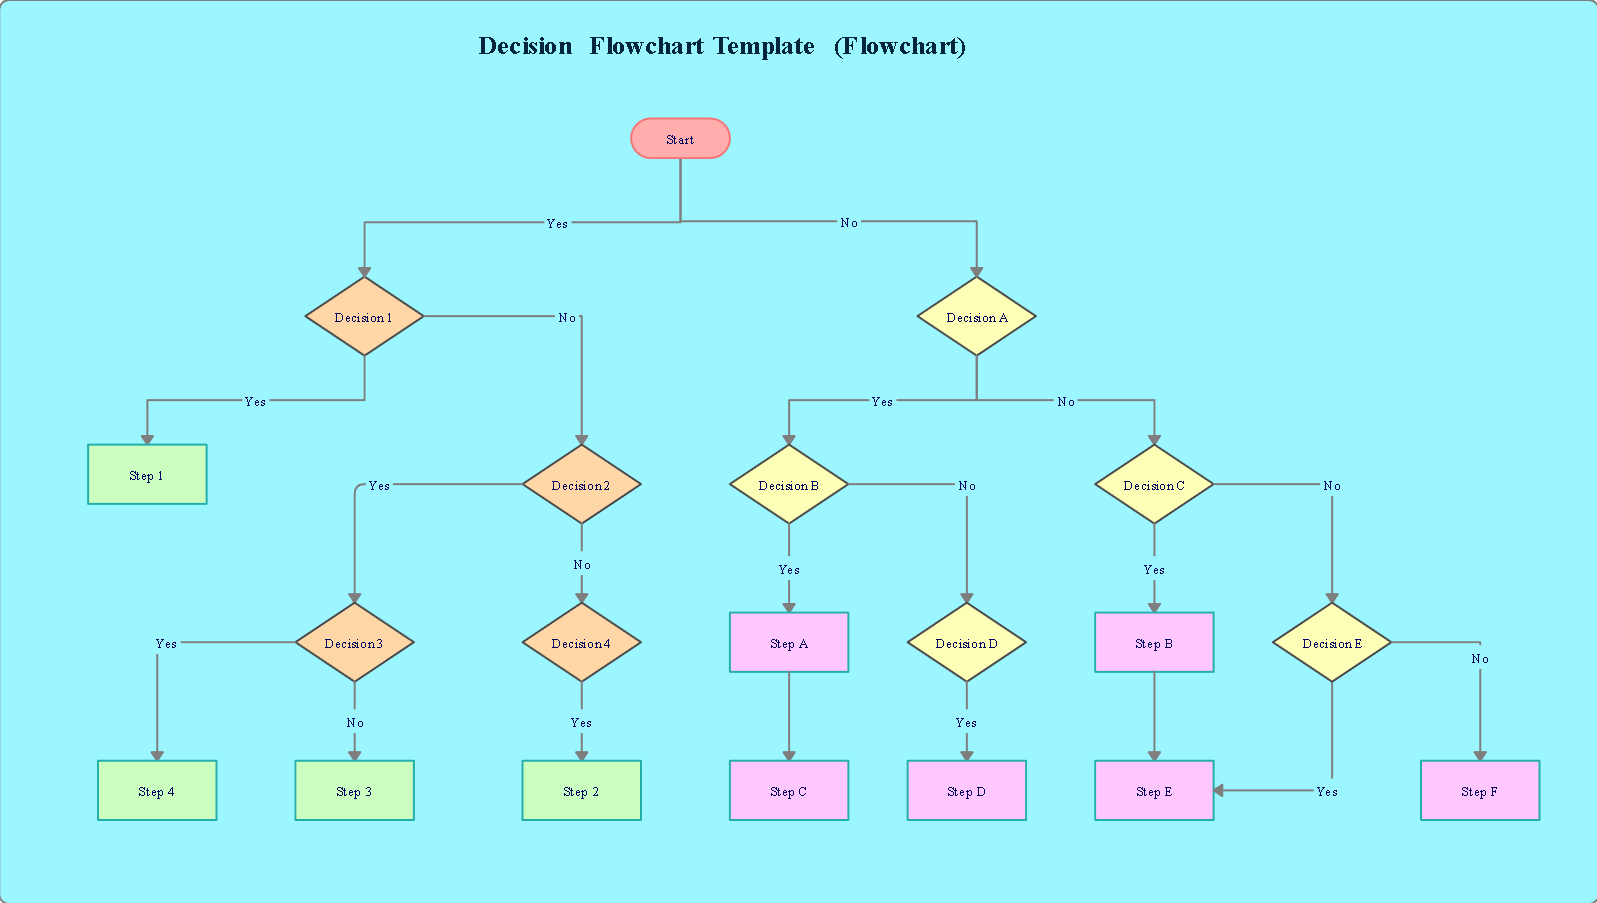<br><br>

CART (Classification and Regression Trees) is a key algorithm for building types of decision trees. It identifies the feature that maximized information gain at each node, creating mode homogenous subsets. This process improves classification accuracy and ensures decision points lead to distinct, meaningful categories.<br><br>

Types of decision trees, like classification trees, are used in practical applications such as medical diagnostics to identify diseases from patient data, and customer segmentation for personalized marketing. Their simplicity, effectiveness, and ability to provide clear decision rules make them an invaluable tool for predictive tasks and actionable insights.<br><br>

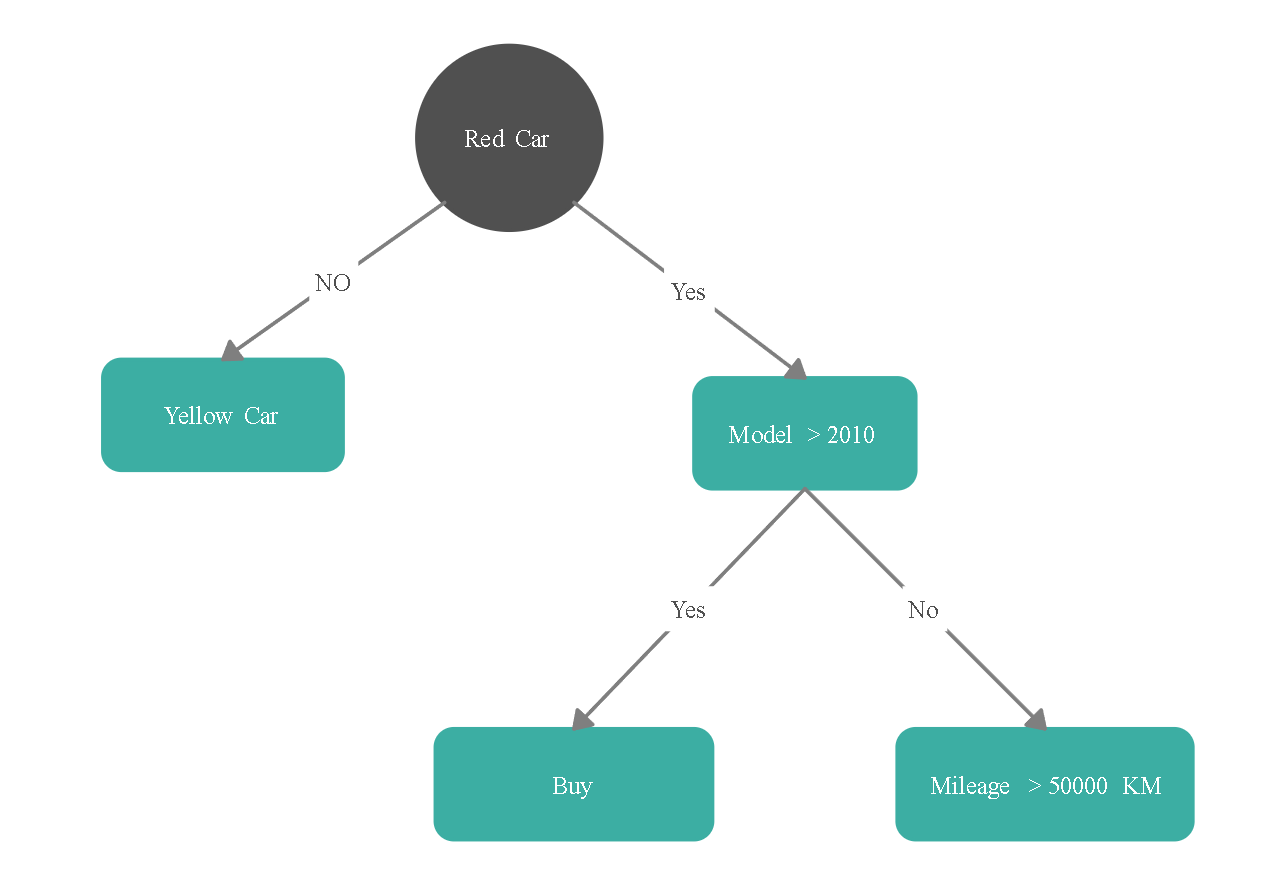<br><br>

Regression Trees -> Predicting Continuous Values<br><br>

Regression trees predict continous numerical outcome, making them essential for predictive modeling. Unlike classification trees, which handle categorical data, regression trees forecast values like future sales or property prices by analyzing historical datasets and identifying key patterns for accurate predictions.<br><br>

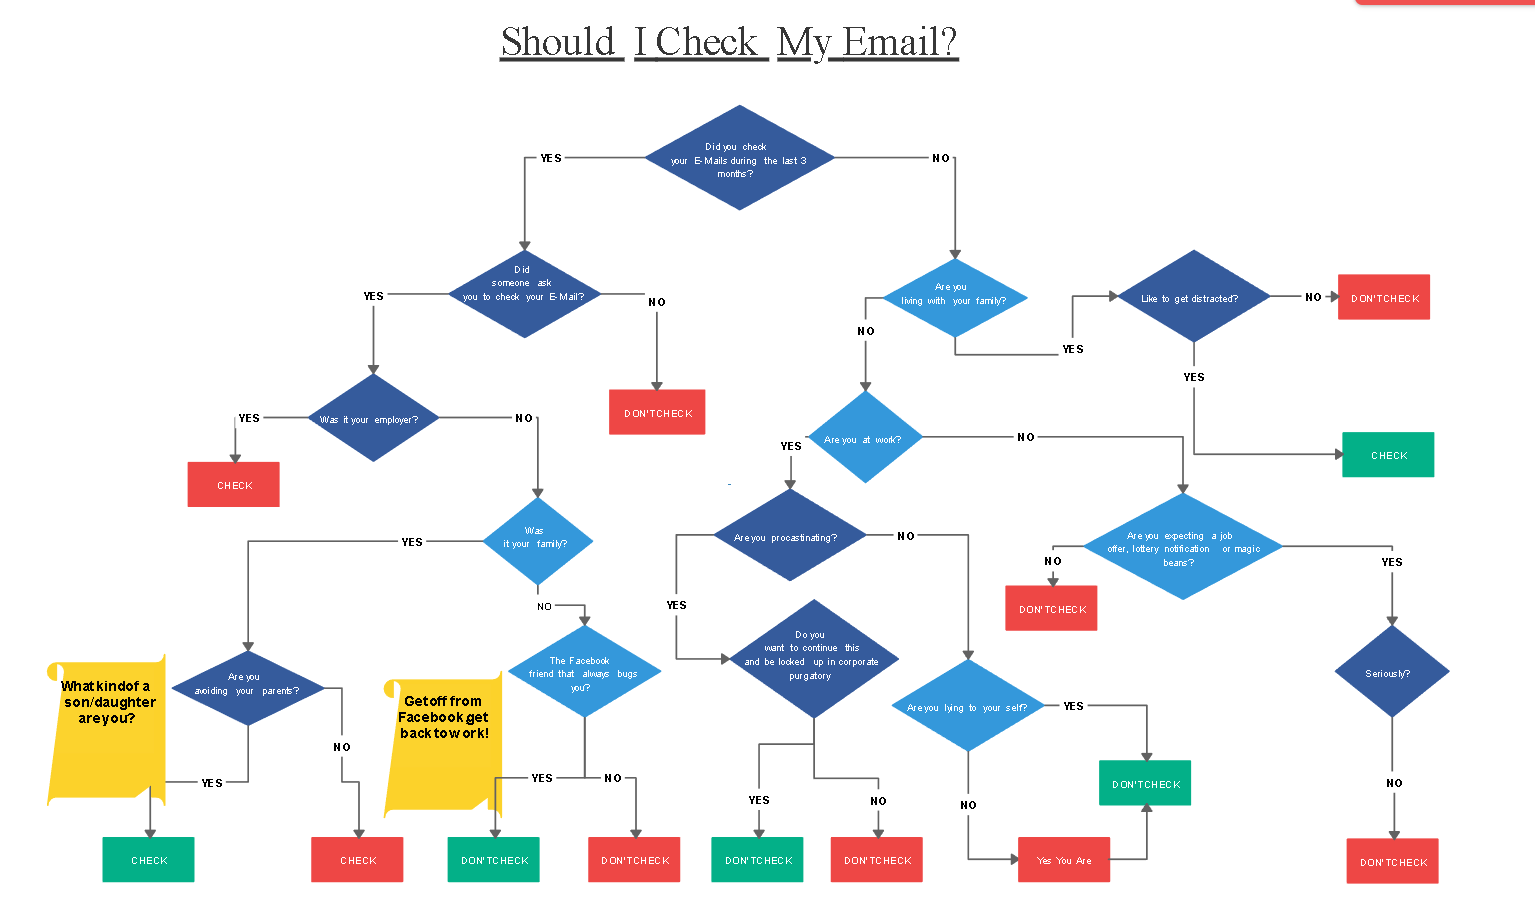<br><br>

CHAID (Chi-squared Automatic Interaction Detector) enhances regression trees by performing multiple splits to refine predictions for continous values. The Reduction in Variance algorithm further improves accurary by focusing on key nodes.<br><br>

Choosing the right type of decision tree - classification for categories and regression for continous data - boosts prediction effectiveness. Creately simplifies this with interactive tools to visualize and build complex models, helping businesses improce decisions and strategic planning with a clear, data-driven framework.<br><br>

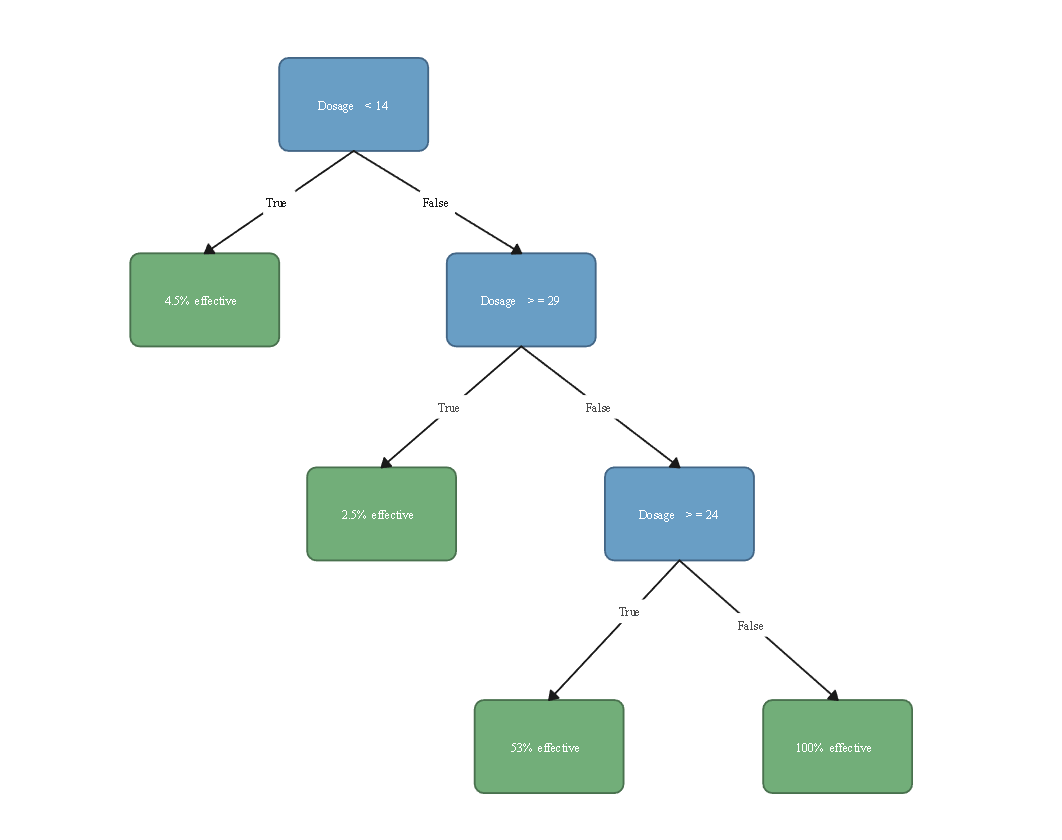<br><br>

11  Types of Decision Tree Algorithms<br><br>

1. Decision Tree Algorithms for Classification<br><br>

Decision tree algorithms are widely used in classification tasks, providing a clear and intuitive way to make data-driven decisions by splitting data into hierarchical branches based on feature values.<br><br>

1.1. ID3 (Iterative Dichotomiser 3)<br><br>

- Purpose -> Classification<br>
- Splitting Criterion -> Information Gain (based on entropy)<br>
- Feature -> Works well with categorical data<br>
          -> Less efficient for continuous data<br><br>

1.2. C4.4<br><br>

- Purpose -> Classification<br>
- Splitting Criterion -> Gain Ratio (an enhancement of Information Gain)<br>
- Features -> Handles both categorical and continours data<br>
           -> Includes pruning techniques to prevent overfitting<br>
           -> Manages missing data effectively<br><br>

1.3. CART (Classification and Regression Trees)<br><br>

- Purpose -> Classification and Regression<br>
- Splitting Criterion -> Gini Impurity for Classification<br>
- Features -> Binary Splits Only<br>
           -> Straightforwatds yet highly effective for most used cases<br><br>

1.4. CHAID (Chi-Squared Automatic Interaction Detector)<br><br>

- Purpose -> Classification<br>
- Splitting Criterion -> Chi-Squared statistical significance test<br>
- Features -> Allows multi-way splits
           -> Commonly used for market research and segmentation<br><br>

1.5. QUEST (Quick, Unbiased, Efficient Statistical Tree)<br><br>

- Purpose -> Classification<br>
- Splitting Criterion -> Statostical tests to ensure unbiased splits<br>
- Features -> Reduces computational time<br>
           -> Effective for unbiased decision-making<br><br>

2. Decision Tree Algorithms for Regression<br><br>

Decision tree algorithms for regression predict continous outcomes by partitioning data into segments and fitting simple models, such as averages, within each region of the tree.<br><br>

2.1. CART (Classification and Regression Trees)<br><br>

- Purpose -> Regression and classification<br>
- Splitting Criterion -> Mean Squared Error (MSE) for regression<br>
- Features -> Binary splits at each node<br>
           -> Handles bath tasks efficiently<br><br>

2.2. MARS (Multivariate Adaptive Regression Splines)<br><br>

- Purpose -> Regression<br>
- Features -> Uses hinge functions to model non-linearity<br>
           -> A flexible extension of regression trees<br><br>

3. Ensemble and Advanced Decision Tree Algorithms<br><br>

Ensemble and advances decision tree algorithms combine multiple decision trees or enhance traditional methods to improve prediction accuracy and handle complex datasets effectively.<br><br>

3.1. Random Forest<br><br>

- Purpose -> Classification and regression<br>
- Feature -> Combines multiple decision trees for better accuracy<br>
          -> Reduces overfitting by aggregating results<br><br>

3.2. XGBoost (eXtreme Gradient Boosting)<br><br>

- Purpose -> Classification and Regression<br>
- Features -> Ensemble of gradient-boosted decision trees<br>
           -> Highly scalable and efficient<br>
           -> Built-in regularization to prevent overfitting<br><br>

3.3. LightGBM (Light Gradient Boosted Machine)<br><br>

- Purpose -> Classification and Regression<br>
- Features -> Faster and more memory-efficient than XGBoost<br>
           -> Uses histogram-based splitting techniques<br><br>

3.4. H2O GBM<br><br>

- Purpose -> Classification and Regression<br>
- Features -> Distributed and scalable for large datasets<br>
           -> High-speed implementation of gradient-boosted trees<br><br>

Types of Decision Trees: Strenghts and Limitations<br><br>

Type -> Classification Tree<br>
Strenghts -> Excellent for catgorizing data into predefined classes<br>
          -> Easy to interprent results<br>
          -> Handles both categorical and numerical data<br>
Limitations -> Car overfit with complex datasets<br>
            -> Struggles with continous target values<br><br>

Type -> Regression Tree<br>
Strenghts -> Ideal for predicting numerical or continous outputs<br>
          -> Handles non-linear relationships effectively<br>
Limitations -> Sensitive to small changes in data<br>
            -> May require pruning to avoid overfitting<br><br>

Type -> CART (Classification and Regression Tree)<br>
Strenghts -> Combines classification and Regression capabilities<br>
          -> Supports binary splitting for better decision-making<br>
Limitations -> May produce biased splits if not properly tunes<br>
            -> Computationally expensive for large datasets<br><br>

Type -> ID3 (Iterative Dichotomiser 3)<br>
Strenghts -> Uses information gain for accurate feature selection<br>
         -> Suitable for small datasets with categorical values<br>
Limitations -> Cannot handle numerical data directly<br>
            -> Prone to overfitting with noise in the data<br><br>

Type -> Random Forest<br>
Strenghts -> Reduces overfitting by averaging multiple decision trees<br>
          -> Works well with larger datasets<br>
          -> Handles missing values effectively<br>
Limitations -> Difficult to interpret individual trees<br>
            -> Requires significant computational power<br><br>

Type -> C4.5
Strenghts -> Improves upes ID3 by handling both categorical and continous data<br>
          -> Prunes trees to avoid overfitting<br>
Limitations -> Computationally intensive for large datasets<br>
            -> Less accurate on highly noisy data<br><br>

Type -> CHAID (Chi-Squared Automatic Interaction Detector)<br>
Strenghts -> Great for market segmentation and statistical analysis<br>
          -> Handles multi-way splits, improving interpretability<br>
Limitations -> Not ideal for small datasets<br>
            -> Assumes linear relationships<br><br>

Type -> Decision Stump<br>
Strenghts -> Simple and fast for one-level decision-making<br>
          -> Works well as a weak learner in ensemble models<br>
Limitations -> Limited predictive accuracy<br>
            -> Overly simplictic for complex datasets<br><br>

Decision trees are a foundational tool in machine learning and data analysis, offering unique strenghts and some limitations. A clear understaing of these aspects is essential for making informed decisions about their application.<br><br>

Advantages of Decision Trees<br><br>

1. Simplicity and Interpretability -> Decision trees are highly intuitive, presenting data in visual, starightforward format. Their transparency allows even non-technical stakeholders to easily interpret the results without delving into complex algorithms.<br>
2. Versatility -> Decision trees can handle a wide range of tasks, including classification and regression problems. They are equally effective with both numerical and categorical data, making them applicable across various domains.<br>
3. No Need for Feature Scaling -> Unlike many machine learning models, decision trees do not require scaling or normalization. They can process raw, unprocessed data directly, saving time and effort in preprocessing.<br><br>

Disadvantages of Decision Trees<br><br>
1. Overfitting -> Decision trees are prone to overfitting, especially when they become too complex. This can result in capturing noise instead of actual data patterns, reducing performance on new, unseen data.<br>
2. Bias Towards Multi-level Features -> Trees may favour features with multiple levels or categories, potentially skewing predictions and reducing model accuracy.<br>
3. Instability -> Decision trees are highly sensitive to small changes in the dataset. Even monor variations can lead to significant changes in the tree structure, making them less robust in dynamic data environments.<br><br>

Comparing Types of Decision Trees with Other Algorithms<br><br>

Compared to other machine learning models, deicison trees excel in their interpretability and accessibility. While more complex algorithms like neural networks may perform better on intricate, non-linear relationships, they lack the transparency of decision trees. For example:<br><br>

- Decision Trees -> Ideal for scenarios requiring explainability, such as regulatory compliance<br>
- Neural Networks -> Better suited for complex problems but opeate as black-box models with less interpretability<br><br>

Neural Network Template: <br><br>

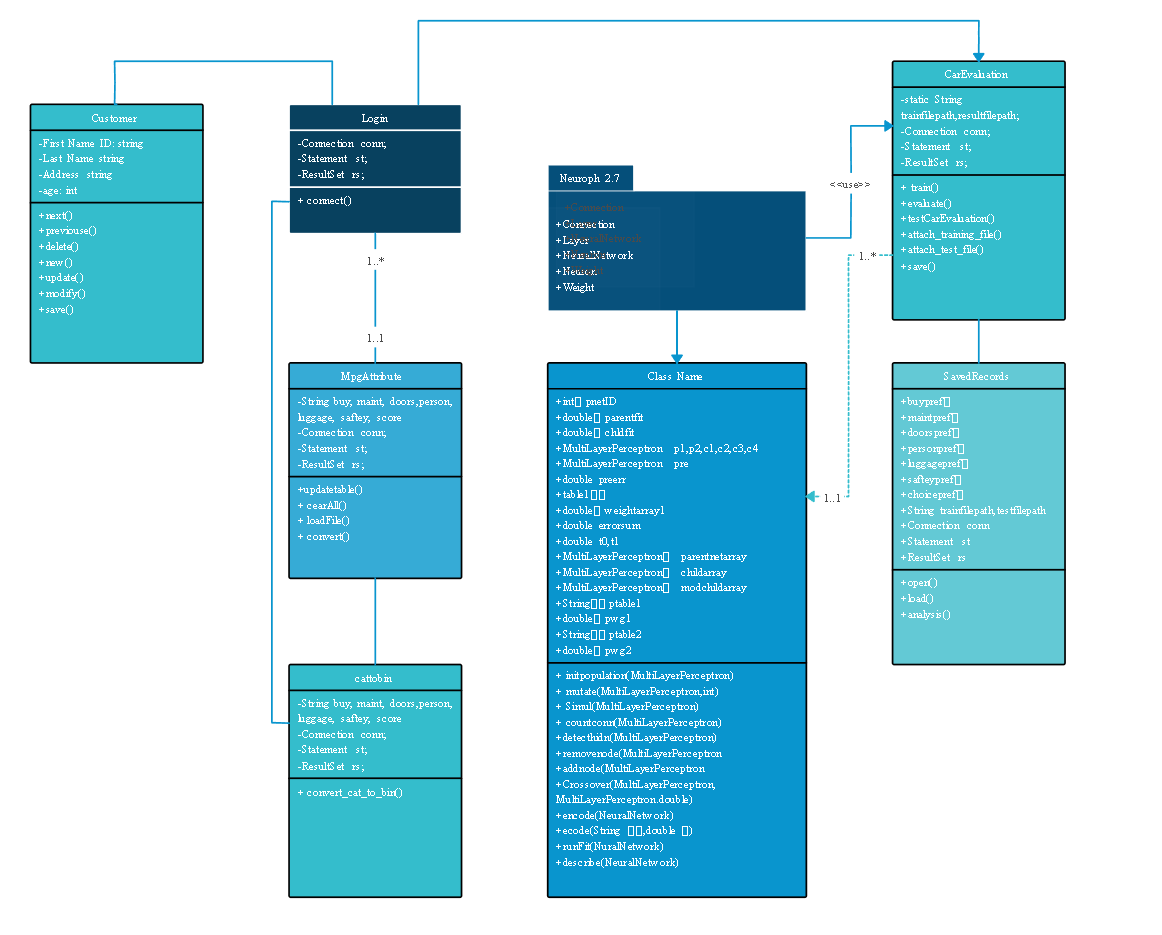<br><br>

Here is a comparative table between decision trees and neural networks:<br><br>

Aspect:<br>
Decision Trees -> High - Easy to understand and visualize<br>
Neural Networks -> Low - Operates as a balck-box model<br><br>

Complexity Handling:<br>
Decision Trees -> Effective for simpler, linear to moderately complex problems<br>
Neural Networks -> Excels at handling complex, non-linear relationships<br><br>

Feature Requirements:<br>
Decision Trees -> No feature scaling needed<br>
Neural Networks -> Required feature scaling and normalization<br><br>

Training Time:<br>
Decision Trees -> Faster to train, especially with smaller datasets<br>
Neural Networks -> Slower to train, particularly with large datasets<br><br>

Overfitting:<br>
Decision Trees -> Prone to overfitting, especially with deep trees<br>
Neural Networks -> Less prone to overfitting, but can occur with improper tuning<br><br>

Robustness:<br>
Decision Trees -> Sensitive to small changes in data (instability)<br>
Neural Networks -> More stable in handling noise and large datasets<br><br>

Use Cases:<br>
Decision Trees -> Ideal for applications requiring clear explanation (e.g., regulatory compliace)<br>
Neural Networks -> Suited for complex prediction tasks (e.g., image recognition, speech processing)<br><br>

Performance:<br>
Decision Trees -> Adequate for simpler tasks, may underperform with high-dimensional data<br>
Neural Networks -> High performance on complex, high-dimensional data<br><br>

Deployment:<br>
Decision Trees -> Easier to implement and maintain<br>
Neural Networks -> Requires more resources and infrastructure for deployment<br><br>

Practical Applications of Types of Decision Trees<br><br>

Decision trees are particularly valuable in situation where explainability is crucial. For instance, in regulatory compliance, they outperform black-box methos like deep learning by providing clear, interpretable decision-making structures.<br><br>

While decision trees have some limitations, their ease of use, interpretability, and adaptability make them indispensable in many analytical toolkits. Exploring algorithm comparisons and understang specific use cases can help maximize their potential in solving data-driven problems.<br><br>

Healthcare and Diagnostic Tools<br><br>

In healthcare, decision trees are essential for improving diagnostic accuracy and personalizing treatment. By analysing variables like patient history, symptoms, and lab results, decision trees help in predicting diseases and tailoring treatment paths. This enhances diagnostic precision, optimizes resources allocation, and supports healthcare systems like health informatics and electronic health recors. Tools like Creately's Decision Tree Example help healthcare proffesionals visualize and compare treatment options, promoting collaboration for intergrated care.<br><br>

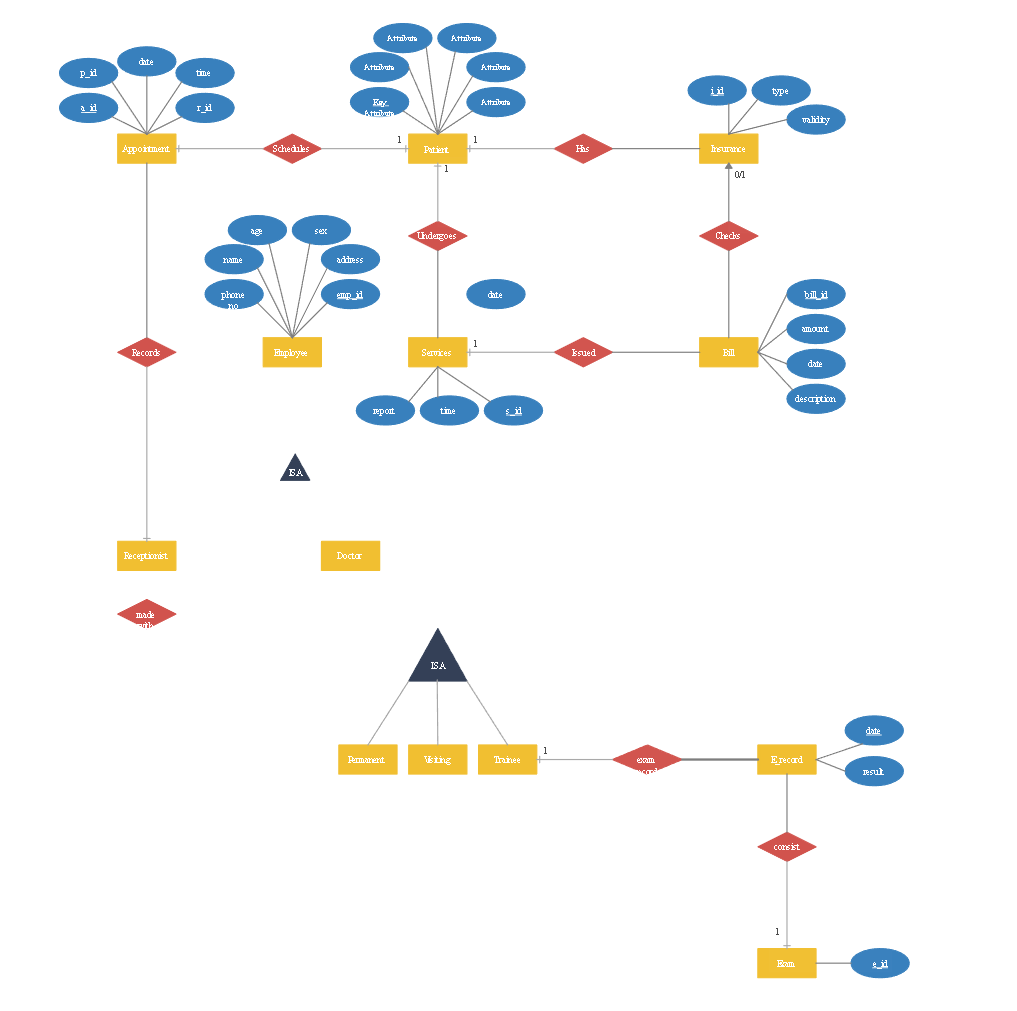<br><br>

Financial Modelling and Risk Assesment<br><br>

Decision trees are vital in finance for risk management and decision-making, especially in credit scoring, investment decisions, and asset pricing. They break down complex financial scenarios into manageble components, helping analysts assess risks and returns. In credit scoring, decision trees forecase default probabilities, aiding informed lending decisions. Financial institutions use them for protofolio optimization and regulatory compliance. Tools like Creately's Decision Tree Analysis Template assists in financial modelling with interactive dashboards, streamlining strategy development.<br><br>

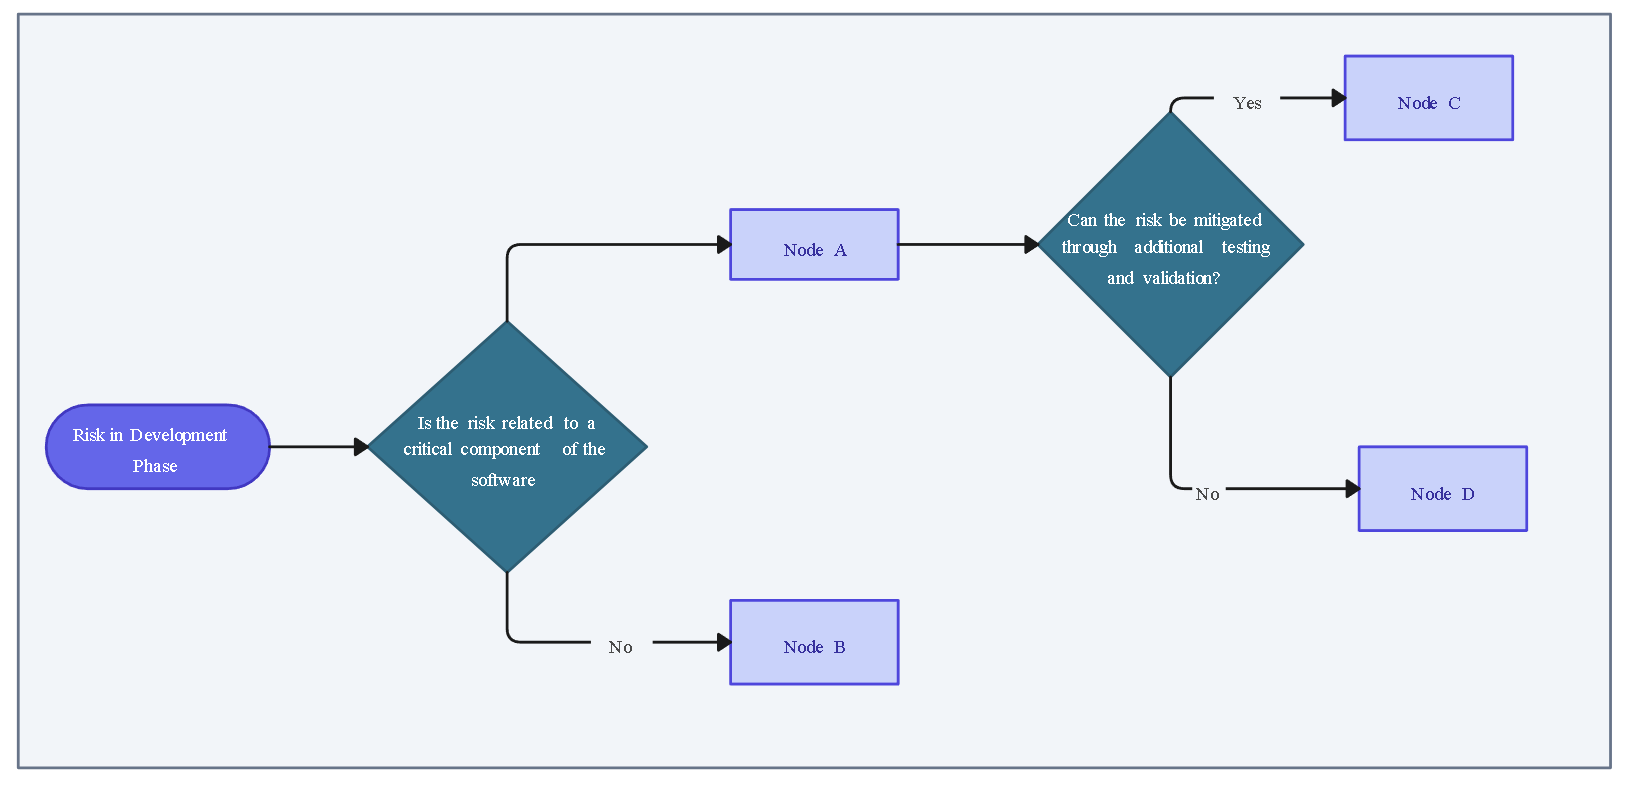<br><br>

Marketing and Customer Segmentation<br><br>

In marketing, decision trees help businesses analyse customer behaviour, segment audiences, and tailor marketing campaigns. By examining purchasing habits, demographics, and preferences, decision trees predict customer responses to producs and services. This allows marketers to optimize engagement strategies and targer advertising for maximum impact. Creately's visual workspace aids marketers in constructing and interpreting decision paths alighning with business objectives.<br><br>

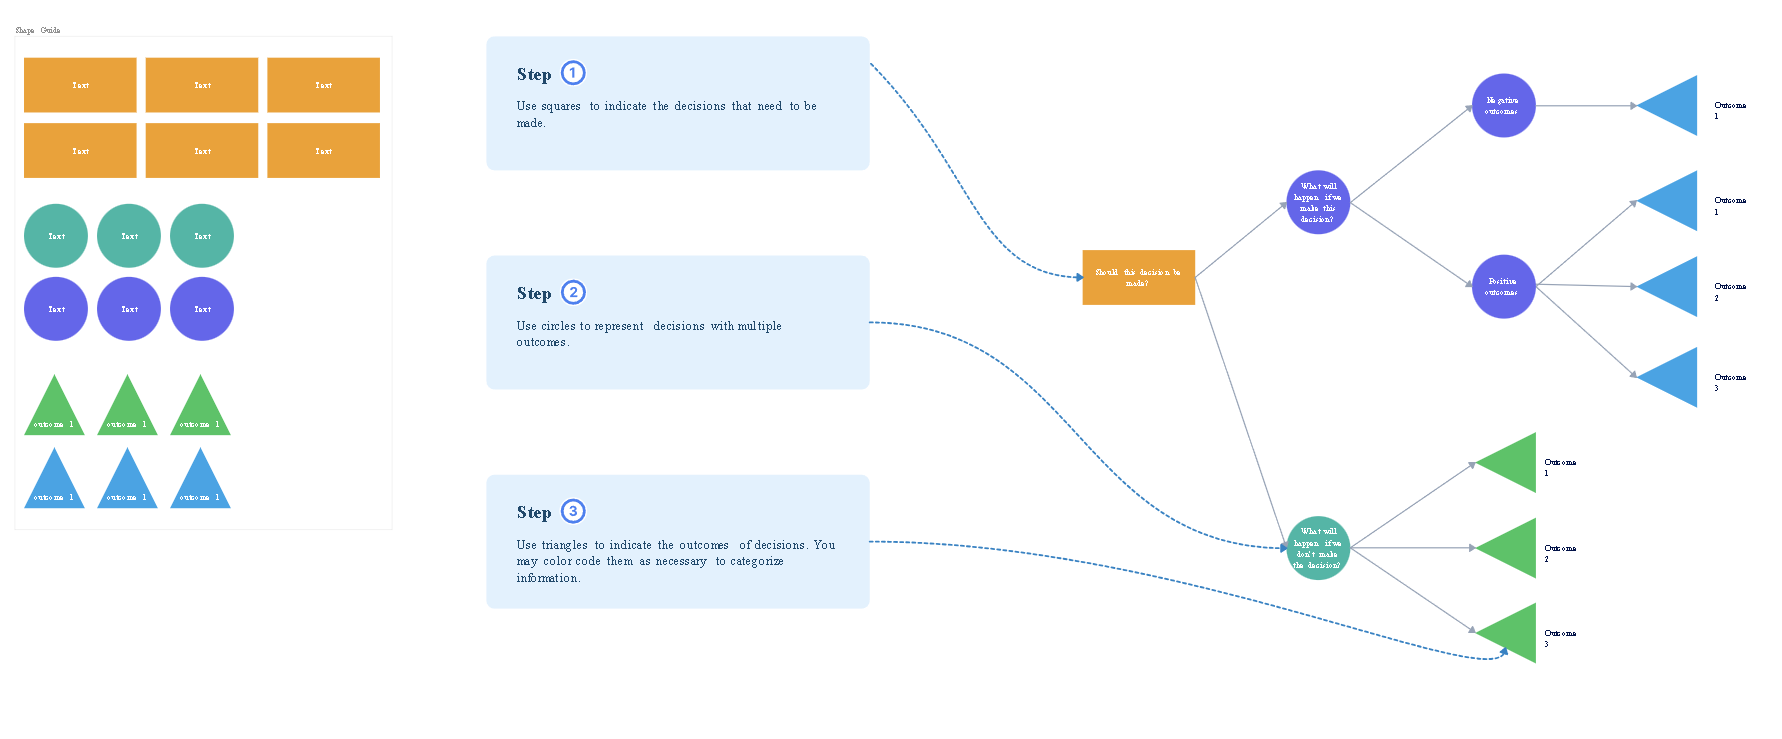<br><br>

Conclusion<br><br>

Decision trees provide a simple yet porwerful approach to machine learning and decision-making. Their strenghts in interpretability, versatility, and ease of use make them an essential tool in fields like healthcare, finance, and marketing. Despite some limitations, such as overfitting and instability, decision trees remain invaluable for clear, data-driven decision-making.<br><br>

https://creately.com/guides/types-of-decision-trees/<br><br>

Decision Tree Algorithms for Classification<br><br>

1.1. ID3 (Iterative Dichotomiser 3)<br><br>

The Iterative Dichotomiser 3 (ID3) algorithm is a decision tree learning algorithm used for solving classification problems. It contructs a tree by selecting attributes that maximize Information Gain, which is computed using entropy. ID3 follows a greedy, top-down recursive strategy to split the dataset until the classification becomes pure or no attributes retain. Let's see some key concepts:<br><br>

- Decision Tree Learning -> Represents classification logic using a tree structure<br>
- Entropy -> Measures impurity or randomness in the target variable<br>
- Information Gain -> Quantifies reduction in entropy after a split<br>
- Greedy Appoach -> Chooses the best split at each step without backtracking<br>
- Cetegorical Attributes -> Originally designed for categorical features<br><br>

Working<br>
Let's see how ID3 works<br><br>

1. Initialize the Dataset -> The algorithm begins by taking the complete training dataset along with the target class attribute. At this stage, all input features are considered as potential candidates for splitting<br><br>

2. Compute Entropy of Target Attribute -> Entropy is calculated for the target class to measure the level of impurity or randomness present in the dataset. This value acts as a baseline for evaliating future splits<br><br>

3. Calculate Information Gain for Each Attribute -> For every input attribute, the dataset is split based on its distinct values and entropy is compared for each subset. Information gain is then calculated as the reduction in entropy caused by splitting on that attribute<br><br>

4. Select the Best Attribute for Splitting -> The attribute with the highest information gain is selected as the decision node because it best separates the data into homogonous classes<br><br>

5. Partition the Dataset -> The dataset is divided into multiple subsets based on the values of the selected attribute. Each subset corresponds to one branch of the decision tree.<br><br>

6. Create Child Nodes Recursively -> The same process of entropy calculation and information gain evaluation is recursively applied to each subset to grow the decision tree further.<br><br>

7. Check Stopping Conditions -> The resursion stops if all instances in a subset belong to the same class, if no attributes are left for further splitting or if the subset becomes empty.<br><br>

8. Assign Class Labels to Leaf Nodes -> When a stopping condition is met, a lead node is created and assigned the majority class label of the corresponding subset.<br><br>

Implementation<br><br>

Step 1: Import the required libraries<br><br>

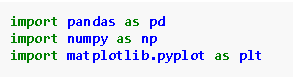<br><br>

Step 2: Entropy Function<br><br>

- Unique class labels and their frequencies are extracted from the target column<br>
- Class probabilities are computed using frequency counts<br>
- Entropy is calculated using the standard entropy formula<br>
- This function measures impurity at any node in the decision tree<br><br>

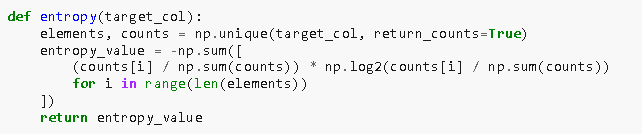<br><br>

Step 3: Information Gain Function<br><br>

- Entropy of the fill dataset is calculated before splitting<br>
- The daset is split based on each unique value of the selected feature<br>
- Entropy is computed for every subset created bu the split<br>
- A weighted sum of subset of entropies is calculated<br>
- Information gain is obtained by subtracting weighted entropy from total entropy<br><br>

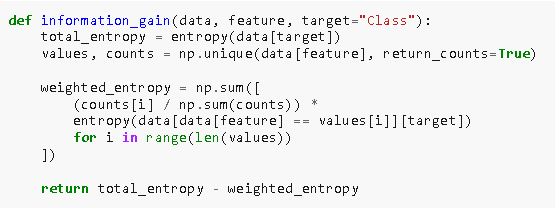<br><br>

Step 4: Recursive ID3 Tree Construction<br><br>

- This function builds the decision tree recursively<br>
- It takes the current dataset original dataset, ramaining features and target column<br><br>

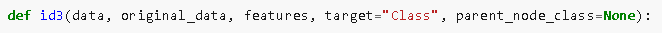<br><br>

Step 5: Handle Stopping Conditions and Mojority Class<br><br>

- Stops recursion when data becomes pure<br>
- Handles empty subsets safely<br>
- Assigns majority class when no features remain<br><br>

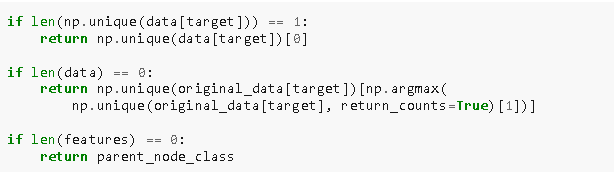<br><br>

Step 6: Select Best Feature and Split Dataset<br><br>

- Identifies the most frequent class for fallback prediction<br>
- Selects the attribute with the highest information gain<br>
- Initializes the decision node<br><br>

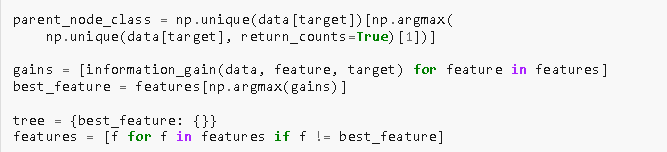<br><br>

Step 7: Recursive Subtree Generation<br><br>

- Splits the data based on feature values<br>
- Recursively builds child nodes<br>
- Attaches sebtrees to the main decision node<br><br>

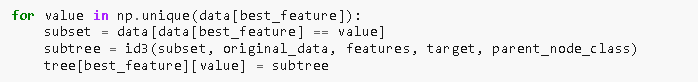<br><br>

Step 8: Execute Model and Output Tree<br><br>

- Dataset is defines and processed<br>
- ID3 algorithm is executed<br>
- Final decision tree is printed as a nested dictionary<br><br>

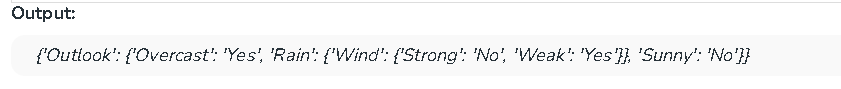<br><br>

Applications<br><br>

- Medical Disgnosis Systems -> ID3 is used to classify diseases based on symptoms and patient attributes by generating interpretable decision rules<br>
- Credit Risk Assessment -> Banks and financial institutions use ID3 to decide loan approval or rejection based on applicat features<br>
- Customer Segmentation -> It helps group customers based on behaviour, preferences or demographics for targeted marketing<br>
- Educational Analytics -> ID3 is applied to predict student performance, dropout risk or grade classification<br>
- Expert Systems -> The algorithm is widely used in rule-based expert systems where decision transparency is required<br><br>

Advantages:<br><br>

- Simple and Easy to Understand -> The tree structure and decision rules produced by ID3 are intuitive and human-readable<br>
- Automatic Feature Selection -> ID3 automatically selects the most informative attributes using information gain<br>
- Non-Parametric Nature -> It does not assume any prior data distributiong, making it flexible for different datasets<br>
- Efficient for Small Datasets -> ID3 performs well and trains quickly on small to medium-sized datasets<br>
- Rule Extraction Capability -> The generated decision tree can be easily converted into if-else rules<br><br>

Limitations<br><br>

- Overfitting Problem -> ID3 does not include pruning, which can lead to overly complex trees<br>
- Bias Toward Multi-Valued Attributes -> Attributes with many distinct values tend to have higher information gain, causing biased splits<br>
- Handling of Continous Data -> ID3 cannot derectly handle numerical attributes without prior discretization<br>
- Sensitivity to Noise -> Noisy or Inconsistent data can significanlty affect the quality of the decision tree<br>
- Greedy Learning Strategy -> The algorithm chooses locally optimal splits and may miss the globally optimal tree<br><br>

https://www.geeksforgeeks.org/machine-learning/iterative-dichotomiser-3-id3-algorithm-from-scratch/<br><br>

Entropy<br><br>

In machine learning, entropy represents uncertanty or randomness in a dataset. Higher entropy means more uncertanty, while lower entropy means more predictable data. It is used to evaluate how well a split separates data into more predictible groups.<br><br>

For large data sets, entropy calculations can quckly become a computational bottleneck that slows down your entire workflow.<br><br>

Fortunately, modern tools make it possible to scale these calculations well, and the right implementation strategies can change your approach to entropy. With the proper oundation and computational resources, you can use entropy's full potential in all your AI projects.<br><br>

Breakdown<br><br>

- Shannon entropy measure uncertanty in data using , with higher values indicating more unpredictable outcomes<br>
- Decision trees use information gain to select optimal splits, reducing entropy at each node for better classification accuracy<br>
- Cross-entropy loss functions guide neural network training by penalizing confident wrong predictions exponentially more than uncertain ones<br>
- GPU acceleration reduces entropy calculation time from hours to minutes for large datasets and complex model training<br>
- Thunder Compute provides cost savings on GPU instances with one-click deployment for entrpoy-based machine learning workflows<br><br>

Shannon Entropy Fundamentals<br><br>

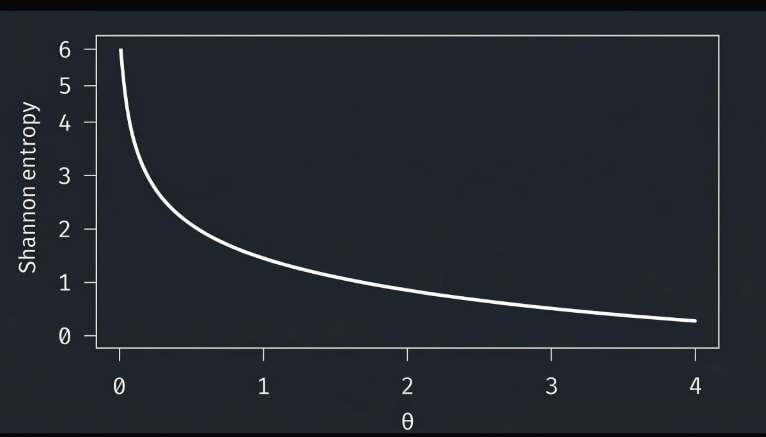<br><br>

Shanning entropy stands as the cornerstone of information theory, fundamentally changing how we mesure undertanty and information content in data. Claude Shannon's 1948 paper introduced this new concept that quantifies the average level of undertanty associated with a variables's potential states.<br><br>

Ai its code, entropy measudre uncertanty in datasets by calculating how much information each observation provides. When all outcomes are equally likely, entropy reaches its maximum value. When one outcome dominates, entropy approaches zero.<br><br>

Shannon entropy provides the mathematical foundation for measuring information content. This makes it invaluable for machine learning algorithms that need to assess data quality and make optimcal decisions.<br><br>

Entropy can be understood as a measure of surprise. A fair coin flip has high entropy because both outcomes are equally probably. A loaded coin that lands heads 99% of the time has low entropy because the outcome is predictible.<br><br>

In mahcine learning, entropy drives critical decisions in algorithms like decision trees, where it determines the best feature for splitting data, it also powers loss functions in neural networks and helps assess model performance across classification tasks.<br><br>

Shannong entropy has many applications -> building decision trees, training neural networks, or implementing supervised fine-tuning.<br><br>

The Shannong Entropy Formula Explained<br><br>

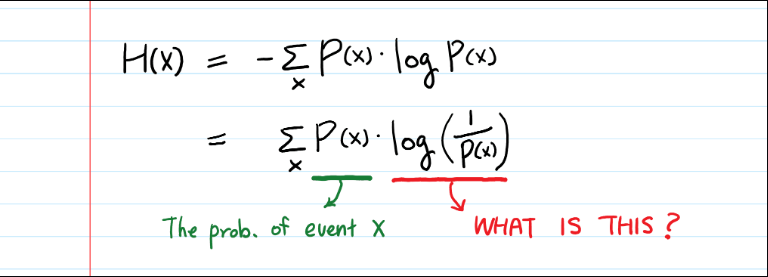<br><br>

The Shannong entropy formula  captures the essence of information measurement. Each component serves a specific purpose in quantifying uncertainty:<br><br>

- x is a discreate random variable<br>
- p(x) is the probability of outcome (x)<br>
- the logarithm is base 2 (when measuring information in bits)<br><br>

The probability {p(x)} shows how likely each outcome is within your dataset. The logarithm  changes these probabilities into information units, where the negative sign keeps entropy values positive since  is negative for probabilities less than 1.<br><br>

Base 2 logarithms are commonly used because they produce results measures in bits, making entropy vealues intuitive to interpret. Each bit equals a single binary decision's worth of information.<br><br>

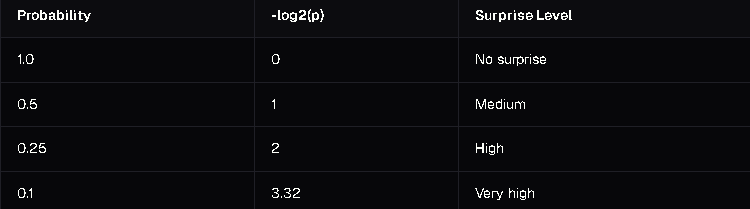<br><br>

The table reveals why rare events carry more information. When probability drops to 0.1, the surprise level jumps to 3.32 bits, indicating that observing this outcome provides substrantial information about the system. The logarithmic relationship means that combining independent events results in additive information content, making entropy calculations mathematically tractable accross complex datasets.<br><br>

Impementing entropy calculations correctly requires careful consideration of edge cases, particularly when probabilioties approach zero. This mathematical foundation becomes important when training models that require substantial computational resources, especially fot CUDA-accelerated training workflows where entropy calculations scale across throusands of data points simultaneously.<br><br>

Entropy in Decision Trees and Information Gain<br><br>

Decision trees use entropy as their fundamental splitting criterion, using information gain calculations to determine optimal feature splits at each node. Information gain measures entropy reduction when changing datasets through feature-based partitions.<br><br>

The information gain formula  compares parent node entropy H(S) agaist weighted child node entropies. Higher information gain indicates better splits that create more homogenous child nodes.<br><br>

Consider a dataset with 8 posititve and 6 negative examples. Parent entropy equals 0.985 bits. If splitting on feature A creates child nodes with entropies 0.811 and 0.592, the weighed average becomes 0.721 bits, yielding information gain of 0.264 bits.<br><br>

The ID3 algorithm selects features with maximum information gain at each step. This greedy approach builds trees that maximize uncertanty at every decision point, creating more accurate classification boundaries. Information gain directly connects with feature importance in tree-based models. Features that consistently provide high information gain across multiple nodes become the most influential predictors in your model.<br><br>

The resursive splitting process continues until entropy reaches acceptable thresholds or stopping criteria are met. Each split reduces overall dataset uncertainty, progressively creating purer leaf nodes that improve prediction accuracy.<br><br>

Cross Entropy Loss Function in Neural Networks<br><br>

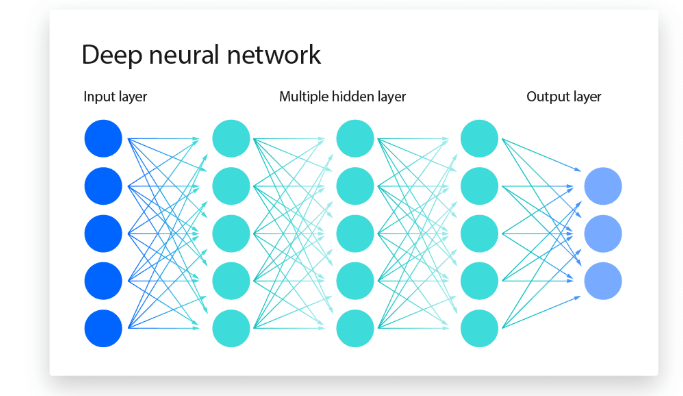<br><br>

Cross entropy loss functions serve as the backbone of neural network training for classification tasks, providing mathematically sound methods for measuring prediction accuracy and guiding gradient descent optimization.<br><br>

Binary Cross Entropy<br><br>

Binary Cross-Entropy (BCE) is defined , where yi represents true labels and pi represents predicted probabilities. This formula elegantly handles both positive and negative cases through its dual-term structure.<br><br>

The logarithm penalty structure makes confident wrong predictions receive exponentially higher penalties than uncertain ones. When a model predicts 0.9 probability for a negative example, the loss jumps dramatically compared to a 0.6 prediction for the same incorrect case.<br><br>

BCE connects directly to maximum likelihoof estimation, making neural network outputs interpretable as probabilty distributions. This probabilistic foundation allows confidence intervals and uncertainty quantification in model predictions. Binary cross entropy's asymmetric penalty structure drives models toward well-calibrated probability estimates instread of just correct classification, improving both accuracy and reliability.<br><br>

Binary cross-entropy during training helps improve predictive accuracy, so the model effectively distinguishes between two classes through optimized deicison boundaries.<br><br>

Categorical Cross Entropy<br><br>

Categorical cross entropy extends binary classification concepts to multi-class scenarios by generalizing the loss calculation across multiple probability distributions. This criterion computes the cross entropy loss between input logits and target classes.<br><br>

The softmax activation function pairs naturally with categorical cross entropy because it changes raw logits into normalized probability distributions. This combination makes sure that predicted probabilities su nto 1.0 across all classes while maintaining differentiability for backpropagation.<br><br>

Entropy Applications Beyond Basic Classification<br><br>

Shannong entropy extends far beyond traditional classification tasks, powering sophisticated machine learning techniques that use uncertainty quantification for enhanced model performance and data understanding and can include:<br><br>

- Mutual Information<br>
- Clustering and anomaly detection<br>
- Regularization and overfitting prevention<br>
- Generative models and active learning<br>
- Memory optimization<br>
- GPU acceleration<br><br>

Mutual Information for Feature Selection<br><br>

Mutual information measures the statistical dependance between variables using entropy calculations. It quantifies how much knowing one variable reduces uncertanty about another, making it invaluable for identifying relevant features in high-dimensional datasets.<br><br>

The formula  reveals how much entropy decreases when conditioning variable X on variable Y. Features with high mutual information scores provide maximum predictive power while eliminating redundant variables that add computational overhead without improving accuracy.<br><br> 

Entropy in Clustering and Anomaly Detection<br><br>

Clustering algorithms use entropy to check partition quality and determine optimal cluster numbers. The entropy-based silhouette coefficient measures how well data points fit their assigned clustered compared to alternative groupings.<br><br>

Anomaly detection uses entropy changes as indicators of unusual patterns. When dataset entropy changes unexpectedly, it signals potential outliers or system anomalies that require investigation.<br><br>

Regularization and Overfitting Prevention<br><br>

Modern machine learning techniques use entropy as regularization terms to prevent overfitting. Entropy regularization encourages models to maintain uncertainty instead of making overconfident predictions on limited training data. Entropy regilarization balances model complexity with generalization ability, making sure that neural networks maintain appropriate uncertainty levels accross diverse input distributions.<br><br>

Generative Models and Active Learning<br><br>

Prebabilistic models use entropy extensively to characterize and manage uncertanty in generative tasks. Variational autoencoders use entropy in their loss functions to balance reconstruction accuracy with latent space regularization.<br><br>

Active learning startegies select training expamples based on prediction entropy, focusing annotation efforts on samples where models express highest uncertainty. This approach maximizez information gain per labeled exampled.<br><br>

During local AI model deployment, advanced entropy implementation should prevent log(O) errors to maintain mathematical accuracy. Catastriphic cancellatuon occurs when substracting nearly equal floating-point numbers during entropy summations. Using higher precision arithmetic or refurmulating calculations can mitigate these stability issues in production environments.<br><br>

Memory Optimization for Large Datasets<br><br>

Streaming entropy calculations processes data in chucks instead of loading entire datasets into memory. This approach allows entropy computation on datasets exceeding available RAM while maintaining computational speed.<br><br>

Sparse data structures reduce memory footprint when working with categorical variables containing many unique values. Hash-based probability counting eliminates the need to store explicit probability arrays for high-cardinality features. Vectorized operations using NumPy or CuPy can accelerate entropy calculations by 10-100x compared to pure Python loops, especially when processing millions of data point simultaneously.<br><br>

GPU Acceleration Startegies<br><br>

Modern Entropy implementations use GPU parallelization to handle massive datasets efficiently. CUDA-optimized libraries like CuPy provide drop-in replacements for NumPy functions that automatically use GPU cores for parellel computation.<br><br>

Thunder Computer for Entropy-Based Machine Learning<br><br>

Entropy-based machine learning workflows demand majour computational resources, especially when processing large datasets or training complex models. Thunder Compute provides the GPU infrastructure needed to accelerate these calculations while maintaining cost-effective performance.<br><br>

Accelerating Decision Tree Training<br><br>

Decsion tree lagorithms perform thousands of entropy calculations during training, checking potential splits across multiple features simultaneously. Thunder Compute's A100 instance allow parallel processing of these calculations, reducing training time from hours to minutes for large datasets.<br><br>

Neural Network Cross-Entropy Optimization<br><br>

Cross-entropy loss calculations scale with batch size and class count. Thunder Compute's high-memory GPU instances handle large batch sizes well, allowing fatsre convergence through stable gradient estimates.<br><br>

In addition, the persistemnt storage features preserves model checkpoints and training state across sessions, allowing you to pause expenside training runs without losing progress. Hardware swapping lets you start development on smaller GPUs and scale to H100s for final training.<br><br>

Information-Theoretic Feature Selection<br><br>

Mutual information calculations require computing entropy across all feature combinations, creating computationally intensive workflows. Thunder Compute's multi-GPU instances parallelize these calculations across feature subsets, dramatically reducing selection time.<br><br>

The full VM control allows custom entropy impementations optimized for your specific data characteristics, while snapshots preserve configures environments for reproducible feature selection experiments across diffeent datatsets.<br><br>

Final thoughts on mastering Shannon entropy for Machine Learning<br><br>

Shannong entropy given you the mathematical foundation to build smarter machine learning models, from optimizing decision trees to training neural networks with better loss functions. The computational demands of entropy calculations across large datasets make GPU acceleration important for practical implementations.<br><br>

Thunder Compute provides cost-effective GPU resources to scale these calculations efficiently, With the right infrastructure and understanding of entropy principles, you can unlock deeper insights from your data and build more accurare predictive models.<br><br>

https://www.thundercompute.com/blog/shannon-entropy-machine-learning-guide<br><br>

Cuda-accelerated workflows -> CUDA Toolkit Explained: How GPU Computing Accelerated AI Workload<br><br>

As Artificial Intelligence, machine learning, and data intensive applications continue to scale, tradictional CPU-based computing is no longer enough. Companies building modern software need faster processing, better performance, and efficient ways to hanndle massive workflows. That's where the CUDA Toolkit comes in.<br><br>

What is the CUDA Toolkit?<br><br>

The CUDA Toolkit is a software development platform that allows developers to use NVIDIA GPUs for general-purpose computing.<br><br>

Instead of relying only on CPUs, CUDA enables GPU accelerated computing, unlocking massive paralled processing power that dramatically improves performance for compute-heavy tasks.<br><br>

The toolkit includes:<br>
- CUDA libaries and APIs<br>
- Compilers for CUDA software<br>
- Debugging and performance analysis tools<br>
- Drivers and runtime components<br><br>

With tools like this developers can build, optimize, and deploy applications that fully leverage modern NVIDIA GPUs. In short, CUDA turns GPUs into programmable engines for high-performance computing.<br><br>

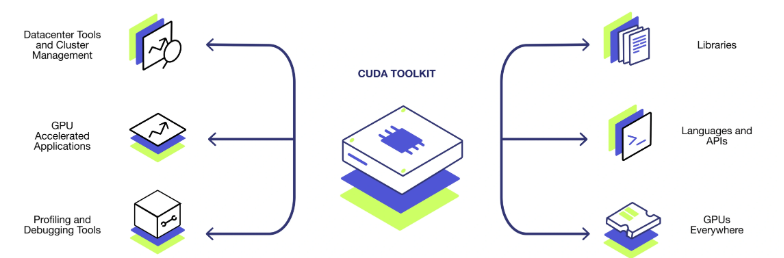<br><br>

How CUDA software enables GPU accelerated computing<br><br>

At its code, CUDA software allows developers to write programs that execute thousands of operations simultaneously on a GPU. This approach is especially powerful for:<br><br>

- Matrix Operations<br>
- Large-scale data processing<br>
- Image and video processing<br>
- Scientific simulations<br><br>

By distrobuting workloads across thousands of GPU codes, CUDA dramatically reduces execute time compared to CPU-only processing. This is why CUDA is widely used in deep learning frameworks, AI inference engines, data analytics pipelines, or even high-performance computing environments.<br><br>

Why is CUDA is so relevant today?<br><br>

1. The Explosion of AI and Machine Learning<br><br>

Modern AI models demans enourmous computational power. Training and running these models without GPUs is ofter impractical. CUDA has become the standard for GPU computing for machine learning enabling:<br><br>

- Faster model training<br>
- Scalable inference workloads<br>
- Efficient handling of large datasets<br><br>

Most popular ML frameworks (like TensorFlow and PyTorch) are built to work directly with NVIDIA CUDA, making it a critical dependency in AI stacks.<br><br>

2. Performance and cost efficiency<br><br>

From a business perspective, CUDA is not just about speed, it is about efficiency. GPU-accelerated workloads can:<br><br>

- Reduce processing time from days to hours<br>
- Lower infrastructure costs by optimizing resource usage<br>
- Improve time-to-market for AI-powered products<br><br>

For companies investing in AI, CUDA helps turn expensive hardware into a competitive advantage.<br><br>

3. Enterprise-grade stability and ecosystem<br><br>

CUDA has been evolving for over a decade, and its ecosystem is mature and well-supported. With each release (including CUDA Toolkit 13.1), the technology introduces:<br><br>

- Performance optimizations<br>
- Better compatibility with modern hardware<br>
- Enhanced security and debugging tools<br><br>

This makes CUDA a reliable choice for production-grade systems.<br><br>

Installing and managing the CUDE Toolkit<br><br>

Getting started with CUDA involved a few essential steps:<br><br>

Installation Process<br><br>

To use CUDA, davelopers must Install CUDA Toolkit on their system. This typically includes:<br><br>

- GPU Drivers<br>
- CUDA Runtime<br>
- Developmnet Libraries<br><br>

The CUDA Toolkit installer varies by operating system (Linux, Windows) and GPU architecture. A proper CUDA Toolkit installation ensures compatibility between your GPU, drivers, and software stacl.<br><br>

Check CUDA Toolkit Version<br><br>

After setup, it is important to check the CUDA Toolkit version to ensure compatibility with your frameworks and drivers.<br><br>

Keeping CUDA versions alighed avoids runtime errors and performance issues, especially in production environments.<br><br>

Why CUDA matters for companies building AI today<br><br>

For companies adopting AI, CUDA is not longer optional, it is foundational.<br><br>

CUDA enables companies to build scalable AI Infrastructure, accelerate experimentation and iteration, and deploy production-ready machine learning systems that can support real-world, high-demand workloads. Whether you are building recommendation engines, computer vision systems, or large-scale data platforms, CUDA makes it possible to move from proof of concept to real-world Impact. As AI workloads continue to grow in complexity, GPU-accelerated computing powered by CUDA will remain a critical pillar of modern software engineering.<br><br>

Conclusion<br><br>

The CUDA Toolkit sits at the intersection of performance, scalability, and innovation, and has become a foundational layer for modern AI development.<br><br>

CUDA plays a critical role in how companies build, operimize, and scale computer-intensive systems, particularly in machine learning and data-driven applications that rely on GPU acceleration. For organizations investing in AI today, and planning for what comes next, leveraging CUDA is a strategic advantage, not just a technical decision.<br><br>

https://www.devlane.com/blog/cuda-toolkit-explained-how-gpu-computing-accelerates-ai-workloads<br><br>

1.2. C4.5<br><br>

The C4.5 algorithm is a successor to the ID3 algorithm. C4.5 was developed by Ross Quinlan with improvements in handling both cathegorical and continous data, as well as handling missing values.While ID3 works well with categorical data, C4.5 introduces a mechanism to handle continous data by selecting optimal thrsholds for splitting. This allows C4.5 to be more versatile in handling different types of datasets.<br><br>

In summary, the C4.5 algorithm is an extension and improvement upon the ID3 algorithm, making it more robust and applicable to a broader range of datasets, including those with continous attributes and missing values.<br><br>

Additionally, C4.5 incorporates a prunning mechanism to avoid overfirring. After building the tree, it may be pruned by removing branches that do not significanlty improve the model's accuracy on unseen data. This helps prevent the tree from becoming too complex and specific to the training data, promoting better generalization.<br><br>

Understanding the drawbacks of the information gain<br><br>

The IDS algorithm is straightforwards to comprehend and implement, especially once we grasp the concept of entropy. However, this simplicity concelas several significant drawbacks. For instance, in the dataset we previously unitilized, the distribution of different values for a specific feature was well spread out.<br><br>

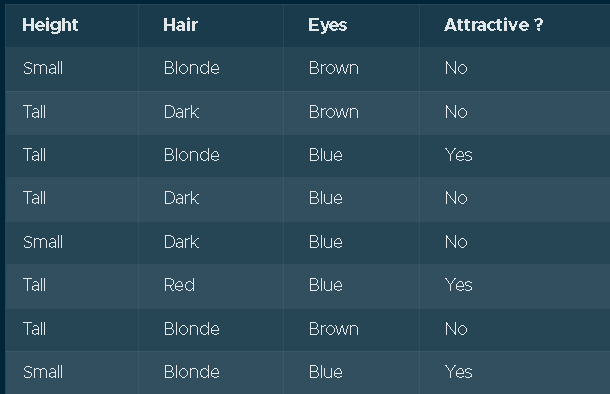<br><br>

Indeed, the dataset comprises of a total of 8 rows. Among these 8 rows, the Height feature has two different values quite evenly distributed (3 Small and 5 Tall), the Hair feature has 3 different values quite evenly distributed (4 Blonde, 3 Dark, and 1 Red), and the Eyes feature had 2 different values quite evenly distributed (3 Brown and 5 Blue).<br><br>

But consider now a dataset where one of the features is the age of a woman's first pregranancy. Typically, in many countires, women have their first children between 20 and 35 years old. However, there may be cases where some women have children after 40 and even up to 50, but these instances are relatively rare.<br><br>

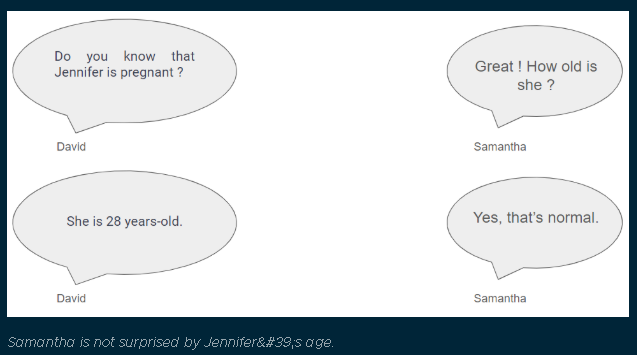<br><br>

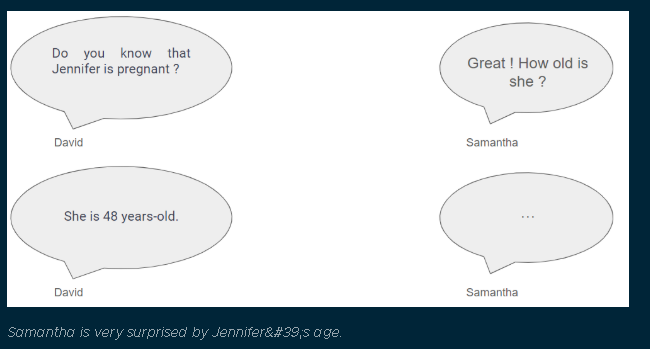<br><br>

The dataset could anyway ressemble the following:<br><br>

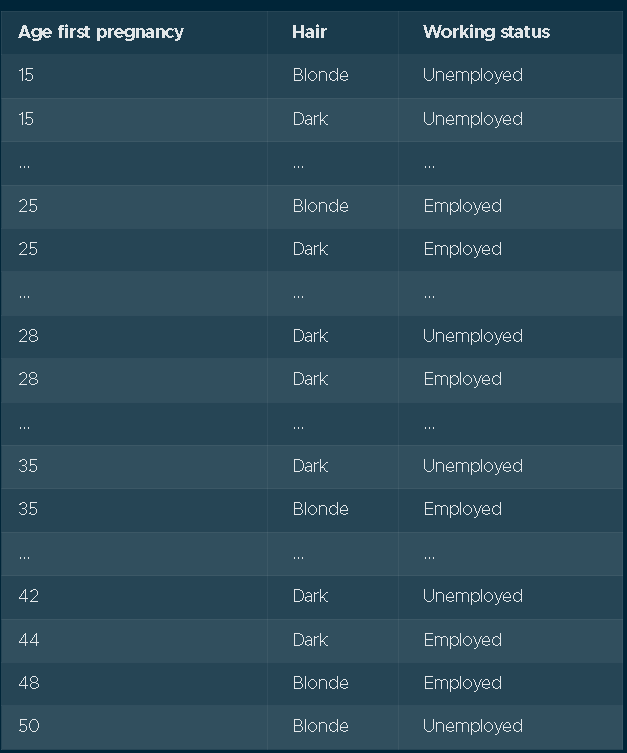<br><br>

This dataset could comprise a total of 10000 rows. Among these 10000 rows, the Age first pregnancy feature has 36 different values that are extremely poorly distributed (800 25, 850 28, 1 44, 0 46, 1 50 for instance). This poor distribution will lead to high entropy (uncertanty is low), resulting in high information gain. Consequently, this feature will be chosen to split the data. But how will the tree be connstructed then?<br><br>

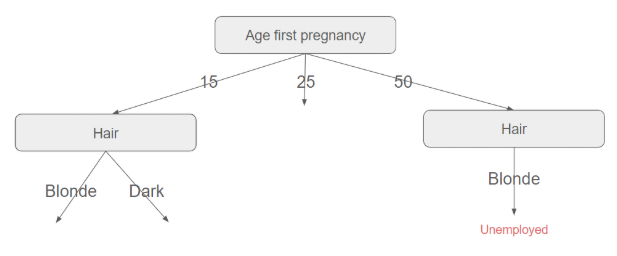<br><br>

The tree will be able to split the data further for women whose age at first pregnancy is 25, 28, or 35. But how can it proceed for the woman whose age at first pregnancy is 50? As there is only one example, it will simply copy the data of this example (with Hair = Blonde). Now, what will happen if a dark-haired 50-year-old woman is tested agaist the decision-tree? As there is no path with these attributed, it will return the only value it can. In fact, here, this portion of the tree is too tailored to the training dataset.<br><br>

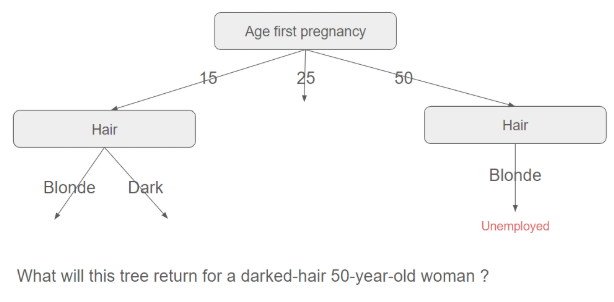<br><br>

This illustrated overfitting -> the dataset fits the training example very well but does not generalize well to other sets.<br><br>

To Remember -> Information gain is biased toward high branching features.<br><br>

Entering Gain Ratio:<br><br>

To mitigate the bias introduced by information gain, another heuristic was proposed by Quinlan and names gain ratio (IGR). He first defines the split information value for a specific feature f as follows:<br><br>

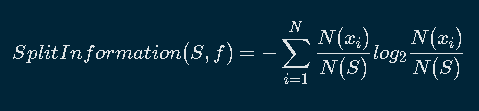<br><br>

x1, x2,..., xN are the different possible values for f and N(xi) are the number of times that xi occurs divided by the total count of events N(S) for all i belonging to [1,N].<br><br>

Then, he defines the gain ratio IGR(S, f) for this feature as simply the ratio of the information gain IG(S, f) and the split information.<br><br>

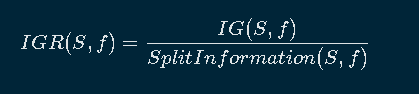<br><br>

The intuition behind this formula is taht low entropy caused by features with a high number of distinct values (like our example above), result in a higher split information. Therefor, the information gain ratio is lower.<br><br>

Worked example:<br><br>

The following example is regarding which features are imprtant for the attractiveness of a person. Below, we have copied the infrmation gains that we had calculated earlier:<br><br>

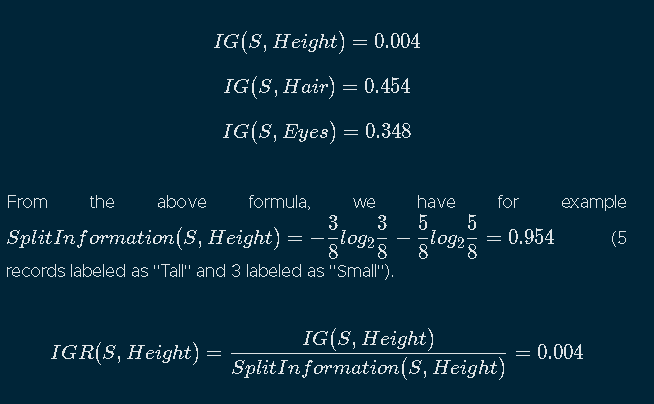<br><br>

The reader is invited to perform the remaining calculations, and we will proceed to present the result below:<br><br>

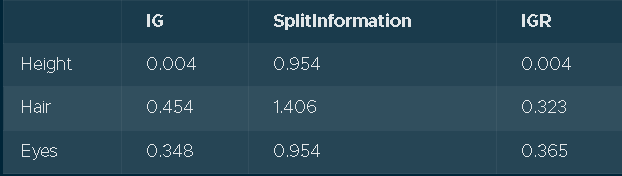<br><br>

In this example, we can observe that the gain ratio has favoured the feature with teh fewer number of distinct values (Eyes, which can take only Brown and Blue) and renalized the Hair feature. Consequently, the data is now split with the Eyes feature list, in contract to the Hair feature as dicussed in the previous post.<br><br>

The C4.5 algorithm (using the gain ratio) is less prone to overfitting compared to its ID3 counterpart.<br><br>

How to deal with continous features?<br><br>

Another limitation of the ID3 algorithm is the challange it faces when dealing with continous variables. The C4.5 algorithm attempts to address this issues and we will modify our example by replacing the Height feature with numerical values to see it in action.<br><br>

The C4.5 algorithm proposes to perform a binary split on a treshold value. This threshold should be a value which offers maximum gain for that attribute.<br><br>

- Sort the different values for Height in the ascending order: 160, 162, ..., 192<br>
- For each value h, partition the records into two froups one with Height values up to and including h and the other with values greater than h<br>
- For each of these partitions, compute the gain ratio<br>
- Choose the partition that maximizes the gain<br><br>

Another worked example:<br><br>

Remember that for our toy example -> H(S) = 0.954<br><br>

- Sort the different values for Height in the ascending order. There are 6 distinct values for the Height feature: 160, 162, 184, 186, 188, 192<br><br>

- For each value h, partition the records into two groups: one with Height values up to and including h (dataset named Hheights <= h) and the other with greater values than h (data names Hheight>h)<br><br>

For h = 160 for instance, Hheight <= 160 comprises 2 records<br><br>

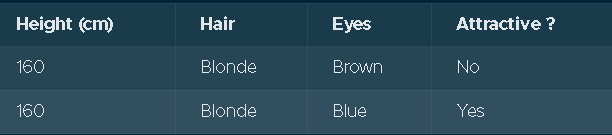<br><br>

Hheight > 160 comprises 6 records<br><br>

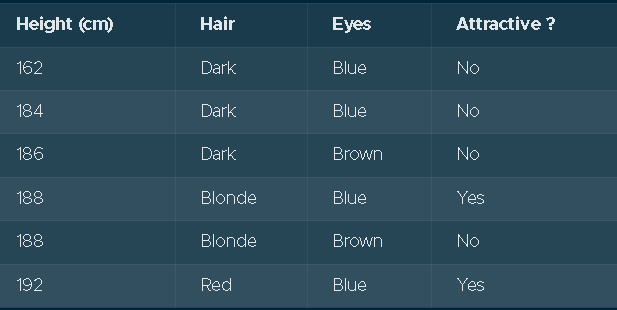<br><br>

- Computer the gain ratio<br><br>

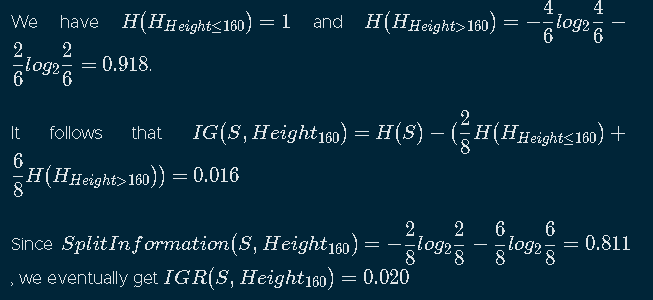<br><br>

- We eventually get IGR(S, Height160) = 0.020<br><br>

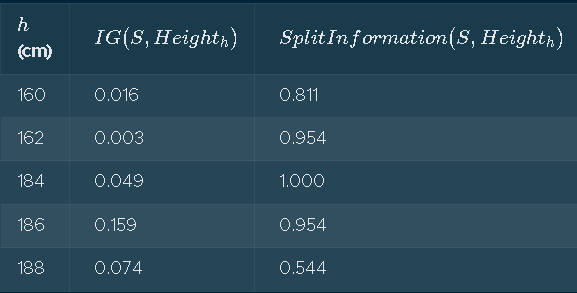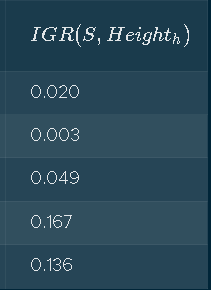<br><br>

- Choose the partitions that maximizez the gain<br><br>

Thus, if we were to split the data using the Height feature, we would need to see the treshold at 186cm<br><br>

This method involves a substantial number of computations.<br><br>

https://www.elementsofcomputerscience.com/posts/implementing-decision-trees-c45-algorithm-04/<br><br>

Another definition:<br><br>

C4.5 is a classic algorithm used for creating decision trees from labeled data. It extends its predecessor, ID3, by adding several practical improvements that allow it to handle real-world datasets more effectively. Below is an informal walkthrough of how the algorithm works, the choices it makes at each step, and some practical considerations for using it.<br><br>

Overview<br><br>

Given a training set 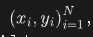 where each xi is a vector of attributes and yi is the class laber, C4.5 builds a tree T that partitions the feature space into regions that ideally contain mostly one class. The construction process is recursive: starting at the root, the algorithm repeatedly selects an attribute and a split point that best separates the data, then creates child nodes and continues until a stopping condition is reached.<br><br>

Attribute Selection<br><br>

At each node, C4.5 elevates all candidate attributes to decide which one to split on. The selection uses the gain ratio measure:<br><br>

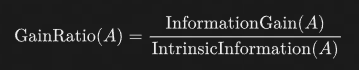<br><br>

- Information gain quantifies how much the entropy of the target variable decreases when partitioning the data by attribute A<br>
- Intrinsic information penalizes attributes that create many small partitions, reducing the risk of overfitting<br><br>

C4.5 then picks the attribute with the highest gain ratio. This process ensures that the chosen attribute offers a good balance between purity and simplicity<br><br>

Handling Continuos Attributes<br><br>

While ID3 could not naturally split continous variables, C4.5 handles them by considering all possible split points s and evaluating the information gain for the binary test A <= s. For each continous attribute, the algorithm sorts the instances by that attribute, examines each pair of consecutine values, and computers the best split point. The attribute and split point with the highest gain ratio become the node's test.<br><br>

Splitting and Recursion<br><br>

Once an attribute and split point are chosen, the data are divided into two (or more) subsets. For catehorical attributes, each distinct value forms a child branch. For continous attributes, the dataset ia partitioned into a left child (values below the split point) and a right child (values above). The algorithm then recursevely builds sub-trees for each child using the same procedure.<br><br>

The recursive stores when one of the following conditions holds:<br><br>

1. All instances in the currect subset belong to the same class<br>
2. No ramaining attributes are available for further splitting<br>
3. The subset size falls below a predefined minimum<br>
4. A maximum tree depth is reached (if such a constraint is imposed)<br><br>

At this point, the node becomes a leaf, and its class label is set to the majority class within the subset.<br><br>

Pruning<br><br>

C4.5 includes a post-pruning step to mitigate overfitting. After the tree is fully grown, the algorithm examines sub-trees and replaces them with leaf nodes if doing so reduces the estimated error. The error is typically estimated using a held-out error estimate (e.g., a bootstrap sample) or a simple error counting method with a small correction term. Pruned sub-trees are thereby simplified, improving generalization on unseen data.<br><br>

Practical Considerations<br><br>

- Missing Values -> C4.5 can handle missing attribute values by distributing instances franctionally across branches based on the observed distribution of knows values<br><br>
- Noise tolerance -> Because of its pruning strategy and use of gain ratyio, C4.5 tends to be robust to noisy data, but exessive noise may still lead to complex trees<br><br>
- Computational cost -> The continous-attribute handling step requires sorting at each node, which can be expensive on larger datasets. However, optimizations such as catching sorted orders can reduce the overhead<br><br>

Example Flow (Illustrative):<br><br>
 
1. Root node -> Evaluate all attributes; suppose attribute Color has the highest gain ratio<br><br>
2. Split -> Create child nodes for each colour value (Red, Green, Blue)<br>
3. Recursive step -> For the Red brach, evaluate remaining attributes; perhaps Size becomes best<br>
4. Repear untill leaves meet stopping criteria<br><br>

The resulting tree can be visualized as a set of decision rules that map attribure values to class predictions<br><br>

C4.5 remains a foundational algorithm in machine learning, providing a clear, interpretable model that balances complexity with predictive performance. Understanding its mechanics, especially the selection criteria and pruning strategy, is essential for applying decision trees effectively in practice.<br><br>

Python Implementation<br><br>

Example of Python Implementation:<br><br>

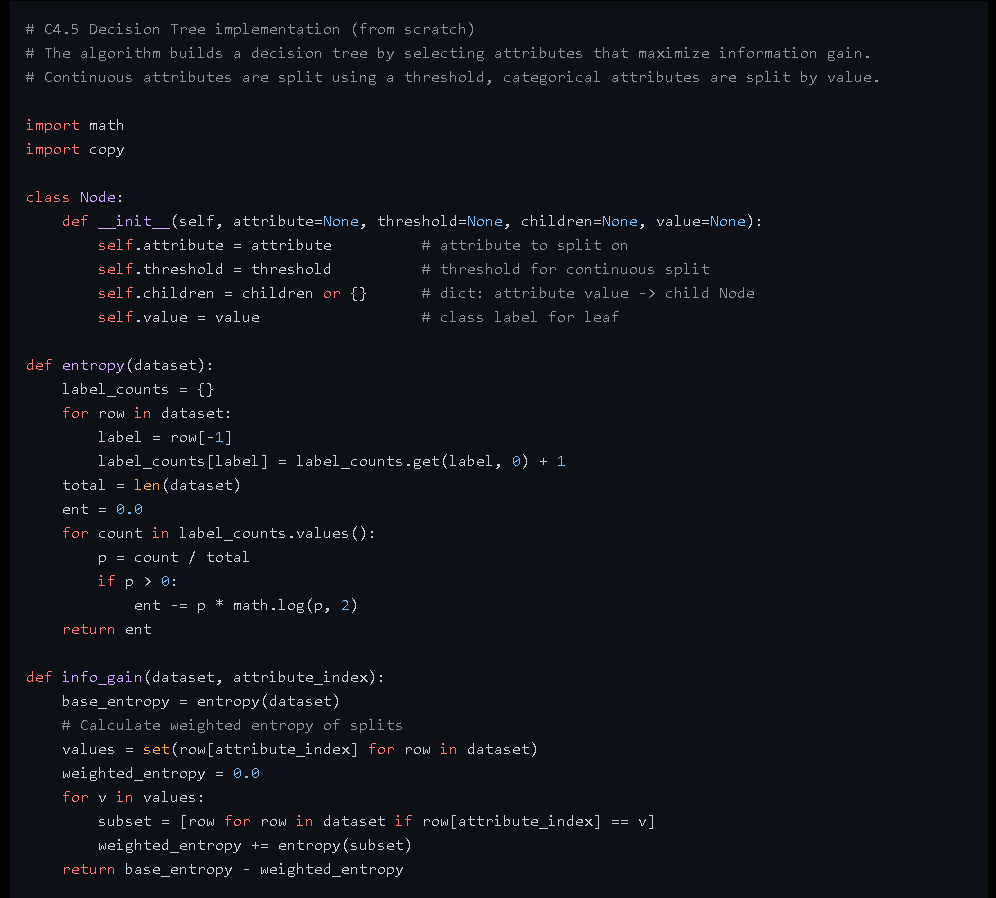<br>
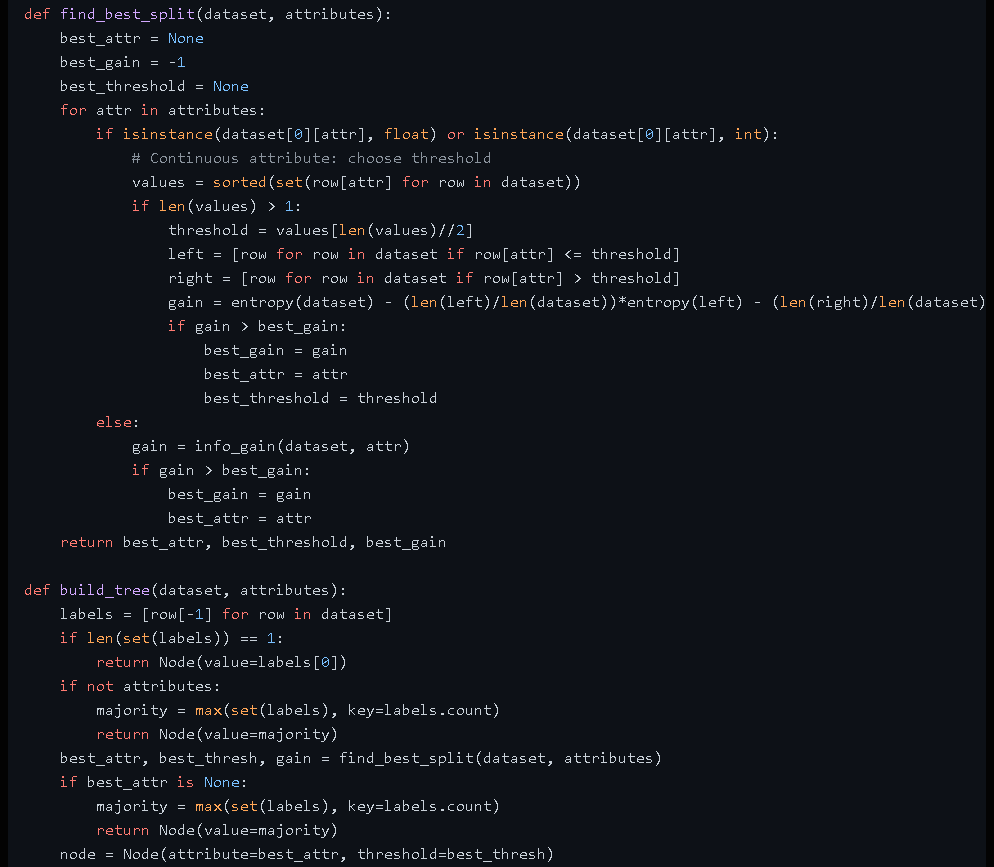<br>
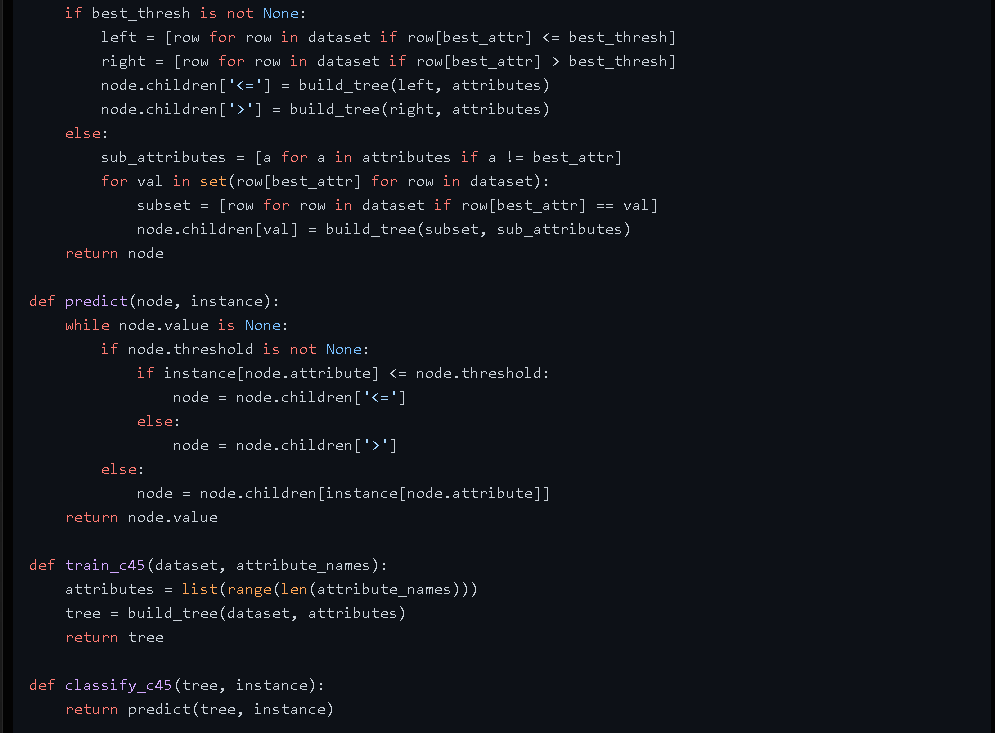<br><br>

Python Repository: https://github.com/every-algorithm/python<br><br>

https://every-algorithm.github.io/2024/11/16/c45_algorithm.html<br><br>

1.3. CART (Classification and Regression Trees)<br><br>

To break a dataset into smaller, meaningfull groups, CART (Classification and Regression Tree) is used which builds a decision tree that predicts outcomes for both classification and regression tasks. It works by splitting data based on rules that reduce error at each step.<br><br>

- Uses binary splits at every node<br>
- Simple to understand and interpret<br>
- Works for both numeric and categorical data<br>
- Forms the base of advanced models like Random Forest, Gradient Boosting and XGBoost<br><br>

How CART Builds a Decision Tree<br><br>

CART (Classification and Regression Tree) constructs a decision tree by recursively splitting the dataset based on the feature and threshold that produce the highest reduction in impurity (for classification) or error (for regression).<br><br>

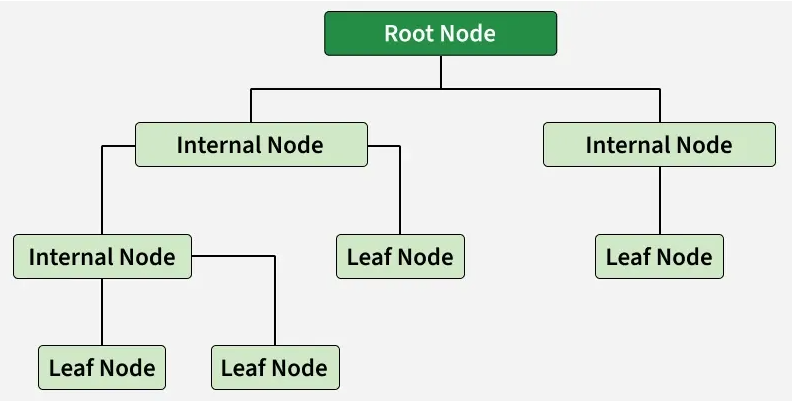<br><br>

Step 1: Evaluate Best Split for Each Feature<br>
- Check all features and their possible split values<br>
- Compute impurity or error<br>
- Identify the split that gives the maximum reduction in impurity or error<br><br>

Step 2: Select the Optimal Split<br>
- Compare impurity decrease for all features<br>
- Choose the feature and threshold pair with the best score<br>
- This becomes the splitting rule for the current node<br><br>

Step 3: Create Binary Child Nodes<br>
- Split the Dataset into Lead Node (values less than or equal to threshold) and Right Node (values greater than or equal to threshold)<br>
- Assign corresponding samples to each child node<br><br>

Step 4: Apply Recursive Splitting<br>
- Repeat the same process for each child node<br>
- Continue until a stopping condition is met<br><br>

CART for Classification<br><br>

CART is used for classification tasks when the output variable is categorical.<br><br>

How it works:<br>

- Recursively splits the dataset to increase class purity at each step<br>
- Uses Gini Impurity to select the best feature and threshold for splitting<br>
- Continues splitting until a stopping rule is met such as maximum tree depth or minimum required samples<br><br>

CART chooses splits that produce the purest possible child nodes<br><br>

CART for Resgression<br><br>

CART is used for regression tasks where the output variable is numerical<br><br>

How it works<br><br>

- Splits the data to minimize residual error between actual and predicted values<br>
- Uses Mean Squared Error (MSE) or Residual Sum of Squares (RSS) as the splitting criterion<br>
- Each leaf node stores the mean of the target values within that node, which becomes the prediction for new samples<br><br>

This helps CART create a tree that provides the lowest possible prediction error<br><br>

Splitting Criteria in CART<br><br>

CART uses different metrics to choose the best splitting rule depending on whether the problem is a classification or regression task. The goal is to find the split that produces the purest child nodes (for classification) or minimum prediction error (for regression).<br><br>

Splitting Criteria for Classification<br><br>

CART uses Ginin Impurity to measure how mixed the classes are in a node.<br><br>

Giny Impurity indicates how likely a randomly chosen samples from the node would be incorrecly classified if it were assigned labels according to class distribution.<br><br>

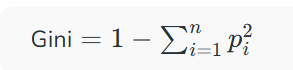<br><br>

Where:<br>
- pi -> proportion of class in i the node<br>
- n -> number of classes<br>
- Gini = 0 -> Node is completely pure (only one class)<br>
- Gini close to 1 -> Node contains a mix of many classes and is highly impure<br><br>

Splitting Criteria for Regression<br><br>

For regression problems, CART uses Residual Sum of Squares (RSS) or Mean Squared Error (MSE) to find the best split.<br><br>

Residual Sum of Squares (RSS) -> RSS measures the total squared difference between actual output values and predicted values.<br><br>

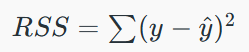<br><br>

Where:<br>
- y -> actual value<br>
- y ^ -> predicted value<br><br>

Mean Squared Error (MSE) -> MSE is simply RSS divided by the number of samples<br><br>

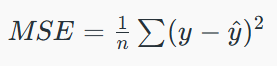<br><br>

Lower RSS or MSE indicates a better split and CART selects the threshold that minimizes the prediction error in the resulting child nodes<br><br>

Pruning in CART<br><br>

Pruning is used to prevent overfitting by trimming branches of the decision tree that add little or no improvement to model accuracy. It simplifies the tree, improves generalization and reduces model complexity.<br><br>

Type of Pruning in CART<br><br>

1. Cost Complexity Pruning -> Removes branches by comparing the trade off between tree accuracy and tree size, keeping only those nodes that significantly improve performance<br>
2. Reduced Error Pruning -> Eliminates nodes that do not improve the model's accuracy on a validation dataset, ensuring only beneficial splits remain<br><br>

Common Stopping or Pruning Criteria Used in CART<br><br>

- Maximum tree depth reached -> The tree stops growing after a predefined maximum depth<br>
- Minimum samples required to split a node -> Splitting stops when a node has fewer samples than the minimum required<br>
- No further improvement in impurity -> If a split does not reduce impurity or error, CART stops splitting<br>
- Node becomes pure -> When all samples belong to one class, no further split is needed<br><br>

Hyperparameters in CART<br><br>

CART provides several hyperparameters to control the tree structure, prevent overfitting and improve model performance. Important hyperparameters include:<br><br>

- max_depth -> Controls the maximum depth of the tree, preventing it from growing too deep and overfitting the data<br>
- min_samples_split -> Specifies the minimum number of samples required to split an internal node; higher values make the tree more conservative<br>
- min_sample_leaf -> Determines the minimum number of samples allowed in a leaf node, helping avoid very samll or unstable leaves<br>
- max_features -> Defines the number of features to consider while looking for the best split; useful for reducing computation and variance<br>
- criterion -> Speficies the function used to evalaluate the split gini or entropy for classification and MSE for regression<br><br>

Step-By-Step Implementation<br><br>

Here we build and evaluate a Decision Tree (CART) model on the Iris dataset, generating predictions, accuracy metrics and visualizations of the trained tree using Matplotlib and Graphviz.<br><br>

Step 1 -> Import Required Libraries:<br><br>

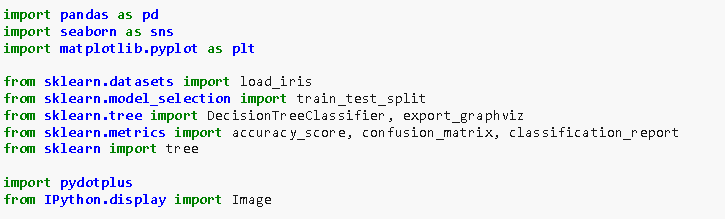<br><br>

Step 2 -> Load and Prepare the Dataset<br><br>

- Convert the dataset into a DataFrame for easier manipulation<br>
- Add the target variable species to the DataFrame<br>
- Separate feature matrix X and target vector y<br><br>

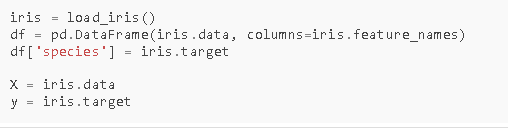<br><br>

Step 3 -> Split Data into Training and Testing Sets<br><br>

- We divice the dataset into training (80%) and testing (20%) using train_test_split<br>
- random_state ensures reproducibility<br>
- Training set is used ot build the model; testing set is used to evaluate the performance of the model<br><br>

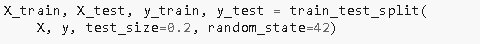<br><br>

Step 4 -> Train the Decision Tree<br><br>

- We create a DecisionTreeClassifier, using entropy as the criterion<br>
- Entropy helps measure impurity for classification tasks<br>
- The model learns patterns from the training data using recursive binary splitting<br><br>

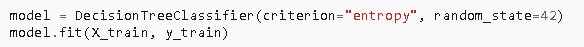<br><br>

Step 5 -> Predictions and Evaluate Model<br><br>

- Predict the output for the test set using model.predict()<br>
- Use a confusion matrix to visualize correct and incorrect predictions<br>
- sns.heatmap() creates a visual representation of the confusion matrix<br><br>

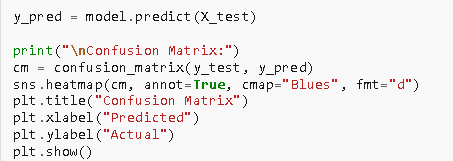<br><br>

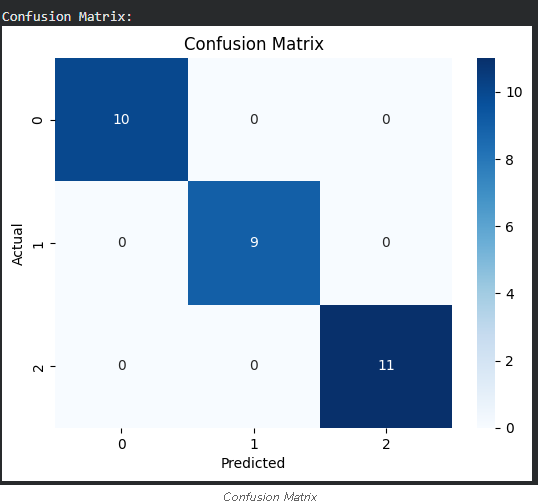<br><br>

Step 6 -> Visualize the Decision Tree<br><br>

- tree.plot_tree() plots the decision tree with node details<br>
- We display features, classes, node colors and structure<br>
- Helps understand how CART split data at each level<br><br>

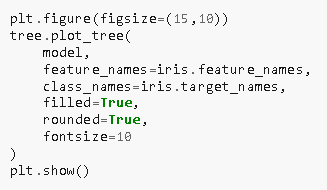<br><br>

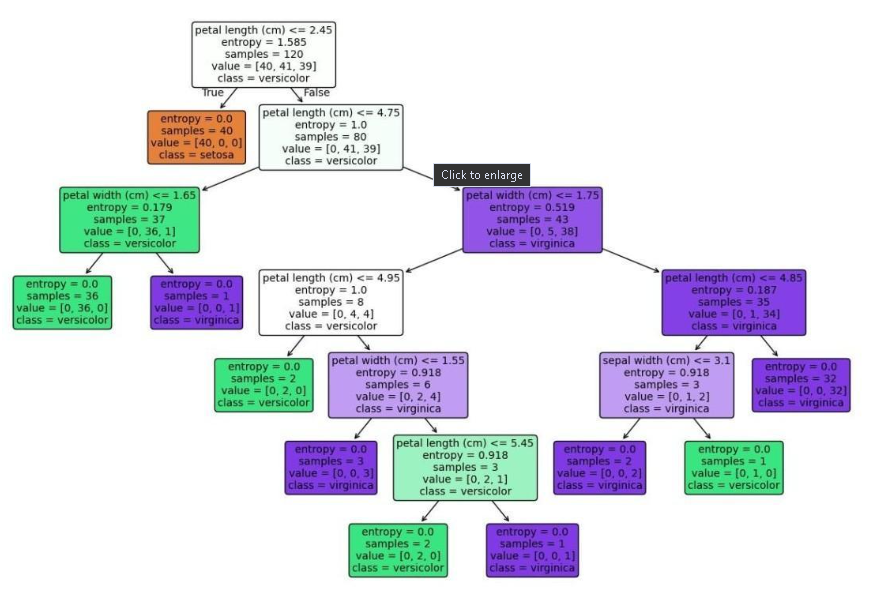<br><br>

Applications<br>
- Medical Diagnosis -> Used to classify diseases based on symptoms, test resilts and patient history<br>
- Blood Donor Classification -> Helps predict whether a person is a suitable and safe blood donor<br>
- Financial Risk Modelling -> Assesses credit risk, loan default probability and fraud detection<br>
- Customer Churn Prediction -> Identifies customers likely to leave a service in telecom, banking or e-commerce<br>
- Environmental Modelling -> Used for predicting pollution levels, weather patterns and ecological changes<br>
- Image and Pattern Recignition -> Helps classify objects, detect patterns and recignize visual features<br><br>

Advantages<br>
- The tree structure is very easy to understand and interpret, making deicision-making transparent and human-readable<br>
- CART handles both regression and classification tasks, supporting numerical as well as categorical targets<br>
- It makes no assumptions about data distribution and works well even without linearuty or normality<br>
- It automatically performs feature selection by choosing the most important splitting features<br>
- It handles non-linear relationships effectively by capturing complex patterns through hierarchical splits<br><br>

Limitations<br>
- CART is prone to overfitting, especially when the tree grows too deep<br>
- It has high variance, meaning small changes in the data can lead to very different tree structures<b>
- The model is sensitive to minor data variations, which can significantly alter the split decisions<br>
- CART performs only binary splits, which may not always be optimal for certain types of datasets<br><br>

https://www.geeksforgeeks.org/machine-learning/cart-classification-and-regression-tree-in-machine-learning/<br><br>

Gini Impurity and Entropy in Decision Tree<br><br>

Decision Trees are classification models that split data into nodes based on feature values. To determine the best split, they rely on impurity metrics that evaluate how mixed a node's class distribution is. Gini Impurity and Entropy are two measures used in decision trees to decide how to split data into branches. Both help determine how mixed or pure a dataset is, guiding the model toward splits that create cleaner groups.<br><br>

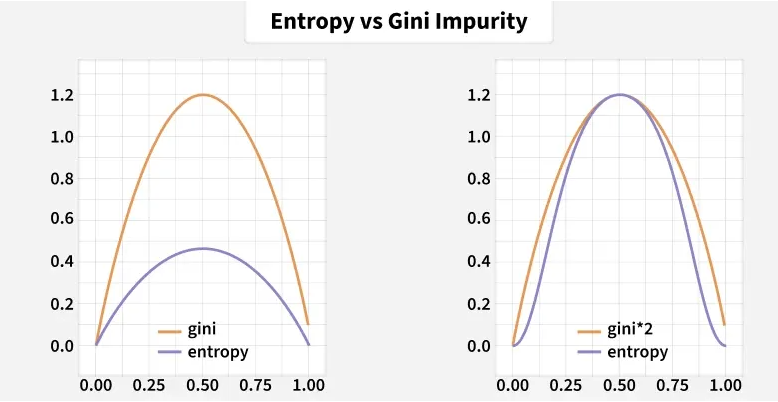<br><br>

Need for Impurity Measures<br><br>

Some common reasons why impurity criteria are essential in decision tree learning are:<br>
- Prevents random or uninformative splits that reduce predictive strenght<br>
- Helps isolate class boundaries for better interpretabilty<br>
- Controls node quality and prevents over-growth of branches<br>
- Reduces classification ambiguity by separating noisy samples<br>
- Maintains model consistency across varied datasets<br><br>

1. Gini Impurity<br>
Gini Impurity checks how often a randomly selected sample would be mislabeled if assigned by class probability. It is computationally simple and used in tree-based classifiers.<br><br>

Formula:<br>
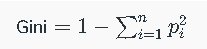<br><br>

Where pi is the proability of class i.<br><br>

Properties:<br><br>

- Lower values indicate cleaner and more homogenous nodes<br>
- Nodes become pure when all samples belong to one class<br>
- Slightly biased toward dominant classes during split selection<br><br>

2. Entropy<br>
Entropy measures uncertainty in a node's class distribution and originates from information theory. Higher entropy indicates greater disorder among class label.<br><br>

Formula:<br>
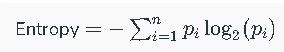<br><br>

Where pi represents the proportion of class i in the node<br><br>

Properties:<br>
- Zero entropy corresponds to perfectly pure splits<br>
- Sensitive to small fluctuations across class rations<br>
- Often yields balanced splits with meaningful boundaries<br><br>

Where to prefer which metric?<br><br>

Some scenarios where one metric may be more practical are:<br><br>

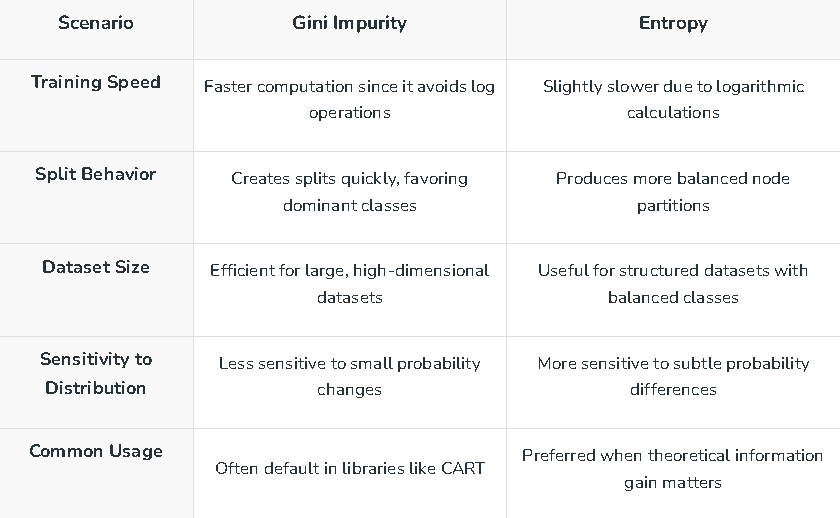<br><br>

Applications<br><br>

Some of the use-cases of impurity metrics are:<br><br>

- Fraud Detection -> Helps differentiate legitimate behaviours from suspicious anomalies, supporting real-time financial monitoring<br>
- Customer Behaviour Classification -> Enables marketing segmentations by grouping users with similar interaction patterns, improving personalized outreach<br>
- Medical Predictions -> Assists in screening symptoms or diagnostic attributes, allowing healthcare systems to classify risk more accurately<br>
- Quality Inspection -> Detects faulty products by separating normal sensor readings from defective patterns with manufacturing pipelines<br>
- Document Categorization -> Organizes incoming text data into relevant topics, improving search and retrival efficiency in large content systems<br><br>

Advantages<br>
Some benefits of impurity based splitting include:<br><br>

- Clear Decision Boundaries -> Each split expresses a simple logical condition, making the model inherently explainable and easy to visualize<br>
- Reduced Ambiguity -> Sibling branches become more homogenous, improving consistency across the tree<br>
- Improved Intermediate Node Quality -> Refined node splits reduce the complexity needed in later branches, enhancing learning efficiency<br>
- Strong Multi-Class Handling -> Effectively separates overlapping classes in datasets with multiple label<br>
- Flexible Metric Choice -> Developers can switch between metrics dependign on dataset behaviour and performance observations<br><br>

Disadvantages<br>
Some disadvantages of impurity metrics are:<br><br>

- Bias Toward Many Unique Values -> Features with many categories may appear informatice artificially, leading to misleading splits<br>
- Sensitivity to Noise and Imbalance -> Noisy datasets or skewed class distribution can distort impurity measurements and reduce accuracy<br>
- Potential for Deep Trees -> Without constraints, impurity-driven expansion can increate depth and complexity unnecessarily<br>
- Need for Pruning -> Additional regularization techniques such as pruning or depth limits are required to control overfitting and maintain generalization<br><br>

https://www.geeksforgeeks.org/machine-learning/gini-impurity-and-entropy-in-decision-tree-ml/<br><br>

Mean Squared Error<br><br>

Mean Squared Error (MSE) is a fundamental concept in statistics and machine learning, playing a crucial role in assessing the accuracy of predictive models.<br><br>

- The MSE value provides a way to analyse the accuracy of the model<br>
- It measures the average squared difference between predicted values and the actual values in the dataset<br>
- It is calculated by taking the average of the squared residuals, where the residual is the difference between the predicted value and the actual value for each data point<br><br>

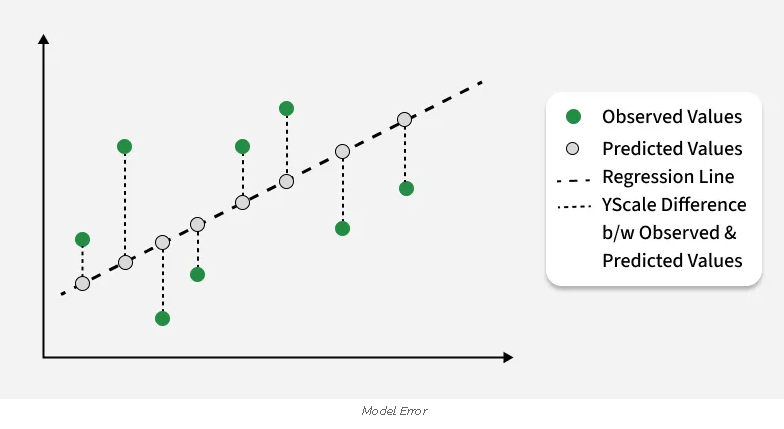<br><br>

Mean Squared Error Formula<br><br>

The formula for the mean squared error is:<br><br>

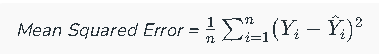<br><br>

Where:<br>
- n is the number of observations in the dataset<br>
- yi is the actual value of the observation<br>
- Y^i is the predicted value of the ith observation<br><br>

Interpretation of Mean Squared Error<br><br>

The Interpreting MSE involves understanding the magnitude of the error and its implications for the model's performance<br><br>

- A lower MSE indicates that the model's predictions are closer to the actual values, signifying better accuracy<br>
- Conversly, a higher MSE suggests that the model's predictions deviate further from the true value, indicating poorer performance<br><br>

Significance of Mean Squared Error<br>
The Mean Square Error is widely used in various fields, including statistics, machine learning, and econometrics, dur to its several important properties:<br><br>
- Regression analysis -> Assessing the goodness of fit of the regression models<br>
- Model evaluation -> Comparing the performance of the different machine learning algorithms<br>
- Optimization -> Minimizing MSE during the model training to improve predictive accuracy<br>
- Predictive modeling -> Evaluating the accuracy of the regression and forecasting models<br>
- Image processing -> Assessing the quality of the image reconstruction and restoration algorithms<br>
- Fiancial modeling -> Analyzing the performance of the investment strategies and risk models<br><br>

How to Minimize Mean Squared Error in Models Training<br>
To minimize Mean Squared Error during the model training, several strategies can be employed, including:<br><br>

- Feature selection -> Choosing relevant features that contribute most to reducing prediction errors<br>
- Model selection -> Experimanting with the different algorithms and model architectures to identify the best-performing model<br>
- Hyperparameter tuning -> The Optimizing model hyperparameters such as the learning rate, regularization strenght, and network depth to improve predictive accuracy<br><br>

Example problems of Mean Squared Error<br>
Example -> Suppose we have a dataset consisting of the actual and predicted values for the regression problem<br><br>

- Actual Values => [10, 20, 30, 40, 50]<br>
- Predicted Values => [12, 18, 32, 38, 48]<br><br>

Solucation:<br>
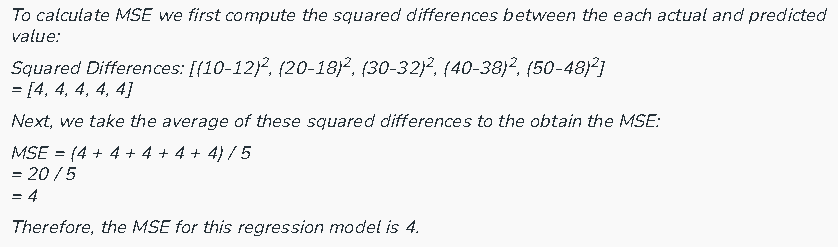<br><br>

Root Mean Square Error<br><br>

The Root Mean Squared Error (RMSE) is a variant of MSE that calculates the square root of the average squared difference between actual and predicted values. It is often preferred over MSE as it provides an interpretable measure of the error in the same units as the original data. RMSE Formula is:<br><br>

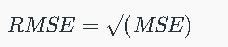<br><br>

Example of Root Mean Square Error<br><br>

Example: Given the actual and predicted values for the regression problem, calculate the MSE and RMSE.<br><br>

- Actual Values: [15, 25, 35, 45, 55]<br>
- Predicted Values: [18, 22, 38, 42, 52]<br><br>

Solution:<br><br>

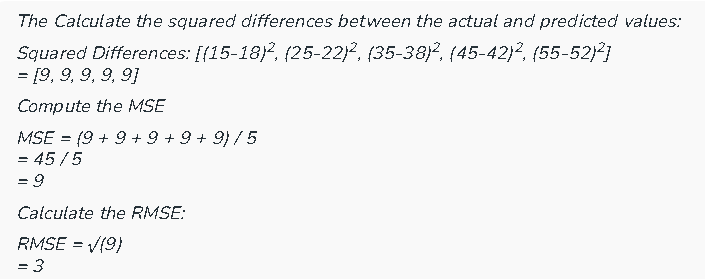<br><br>

MSE VS RMSE VS MAE<br><br>

Mean Squared Error is often compared with other error metrics, such as the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), to evaluate model performance.<br><br>

- While MAE measures the average absolute difference between predicted and actual values<br>
- RMSE measures the square root of the average squared difference<br>
- The MSE and RMSE penalize large errors more heavily than MAE, making them more sensitive to the outliers<br><br>

https://www.geeksforgeeks.org/maths/mean-squared-error/<br><br>

Pruning Decision Trees<br><br>

Decision Trees, when allowed to grow freely, tend to learn noise and very specific patterns from the training data, leading to overfitting. Pruning addresses this issue by simplifying the tree structure, improving generalization to unseen data, enhancing interpretability and reducing computational cost, while maintaining or even improving overall model accuracy.<br><br>

- Reduces overfitting by elimitating noise-driven splits<br>
- Improves generalization on unseen data<br>
- Simplifies the decision tree structure<br>
- Enhances interpretability of decision rules<br>
- Improves training and inference efficiency<br><br>

Decision Tree Pruning is a model optimization technique used to control the growth of decision tree models by removing the unnecessary branches and nodes that do not contribute significantly to predictive performance.<br><br>

Types of Decision Tree Pruning<br><br>

Decision tree pruning techniques and broadly classified into two categories:<br><br>

1. Pre-Pruning (Early Stopping)<br>
Pre-Pruning is also knows as early stopping, is a pruning startegy in which the growth of the decision tree is restricted during the training phase itself. Instead of allowing the tree to grow fully and then trimming it later, pre-pruning prevents certain splits from being created if they do not satisfy predefined constraints.<br><br>

- Controls tree complexity during training<br>
- Prevents unnecessary splits early in the learning proces<br>
- Preduces compact and shallow trees<br>
- Reduces training time and memory usage<br><br>

Working<br><br>

- The decision tree starts growing from the root node using training data<br>
- At each node, the algorithm checks whether a split satisfies predefined conditions<br>
- If the split improves impurity reduction and meets contraints, the node is split<br>
- If the split does not meet conditions, the node is converted into a leaf<br>
- Constrains such as maximum deoth or minimum samples control further growth<br>
- Tree growth stops early before it becomes overly complex<br>
- The final tree remains shallow and simple<br><br>

Common Pre-Prunning Techniques<br><br>

1. Maximum Depth<br>
- Limits the depth of the tree<br>
- Prevents long and complex decision paths<br><br>

2. Minimum Samples per Split<br>
- Requires a minimum number of samples to split a node<br>
- Avoids unreliable splits based on small datasets<br><br>

3. Minimum Samples per Leaf<br>
- Ensures each leaf node contains enough samples<br>
- Reduces sensitivity to noise and outliers<br><br>

4. Maximum Features<br>
- Limits the number of features considered at each split<br>
- Introduces randomness and reduces overfitting<br><br>

2. Post-Pruning (Pruning After Full Growth)<br><br>

Post-Pruning is a pruning startegy in which the decision tree is allowed to grow to its full depth first, after which unnecessary or weak branches are removed. Unlike pre-pruning, this approach does not resctict the tree during training. Instead, it analyzes the fully grown tree and evaluates whether certain subtrees contribute meaningfully to predictive performance.<br><br>

- Applied after the tree is fully grown<br>
- Uses validation or test performance for prunning decisions<br>
- Produces well-balanced trees with better generalization<br>
- Typically results in higher predictive stability<br><br>

Working<br><br>

- The decision tree is grown completly using the training dataset<br>
- All possible splits are created without restricting tree depth<br>
- The fully grown tree is then evaluated using validation or test data<br>
- Branches that do not improve prediction accuracy are identifies<br>
- Weak or unnecessary subtrees are removed from the tree<br>
- Removed branches are replaced with leaf nodes<br>
- The final tree is simpler while maintaining strong generalization performance<br><br>

Common Post-Pruning Techniques<br><br>

1. Cost-Complexity Pruning (CCP)<br>
- Introduces a penalty for tree complexity<br>
- Uses a pruning parameter (lambda) to balance accuracy and size<br><br>

2. Reduced Error Pruning<br>
- Removes branches that do not improve validation accuracy<br><br>

3. Minimum Impurity Decreases<br>
- Prunes nodes with very small impurity reduction<br><br>

4. Minimum Leaf Size<br>
- Removes leaf nodes with insufficient samples<br><br>

Implementation<br>
Let's see the implemantation using the Breast Cancer dataste from scikit-learn<br><br>

Step 1: Import Libraries and Load Dataset<br><br>

We need to import the required libraries and load the dataset from scikit-learn:<br><br>

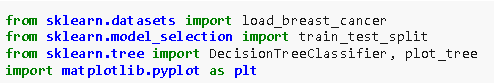<br><br>

Step 2: Split the Dataset<br><br>

- Loads features and labels<br>
- Splits data into training and testing sets<br>
- Ensures reproducibility using a fixed random state<br><br>

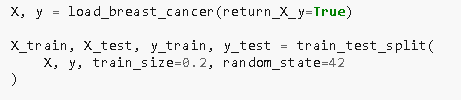<br><br>

Step 3: Train the Oiginal (Unpruned) Decision Tree<br><br>

https://www.geeksforgeeks.org/machine-learning/pruning-decision-trees/<br><br>

1.4. CHAID (Chi-squared Automatic Interaction Detector)<br><br>

1.5. QUEST (Quick, Unbiased, Efficient Statistical Tree)<br><br>

Decision Tree Algorithms for Regression<br><br>

2.1. CART (Classification and Regression Trees)<br><br>

2.2. MARS (Multivariate Adaptive Regression Splines)<br><br>

Ensemble and Advances Decision Tree Algorithms<br><br>

3.1. Random Forest<br><br>

3.2. XGBoost (eXtreme Gradient Boosting)<br><br>

3.3. LightGBM (Light Gradient Boosted Machine)<br><br>

3.4. H2O GBM<br><br>

In [6]:
# ============================================================
# DECISION TREE
# Easy to interpret. No scaling needed. Can overfit.
# Look for high training accuracy but lower test accuracy (overfitting).
# ============================================================

from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)  # no scaling needed

y_pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))


Decision Tree Accuracy: 0.9518716577540107


Test Accuracy: 0.9519
Train Accuracy: 1.0000
If Train >> Test, the model is overfitting.

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95        94
           1       0.92      0.99      0.95        93

    accuracy                           0.95       187
   macro avg       0.95      0.95      0.95       187
weighted avg       0.95      0.95      0.95       187



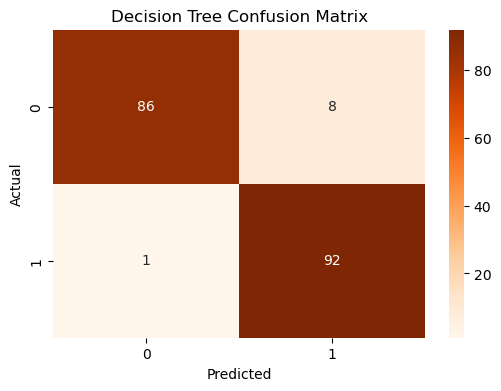

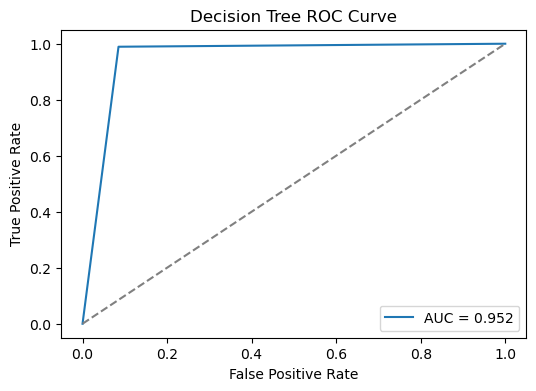

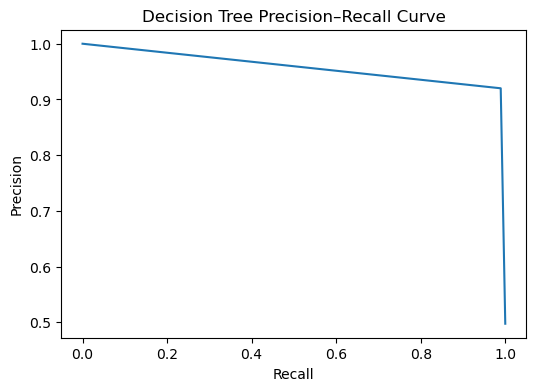


Feature Importance:
                          Feature  Importance
9           Water_Intake (liters)    0.506969
2                      Height (m)    0.201165
8                  Fat_Percentage    0.112306
1                     Weight (kg)    0.103372
6        Session_Duration (hours)    0.038151
7                 Calories_Burned    0.010022
12                            BMI    0.008910
4                         Avg_BPM    0.005646
10  Workout_Frequency (days/week)    0.004302
15                   Workout_Yoga    0.004033
13                   Workout_HIIT    0.003585
3                         Max_BPM    0.000869
0                             Age    0.000670
5                     Resting_BPM    0.000000
11               Experience_Level    0.000000
14               Workout_Strength    0.000000


C:\Users\Admin\AppData\Local\Temp\ipykernel_14172\2820223216.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='autumn')


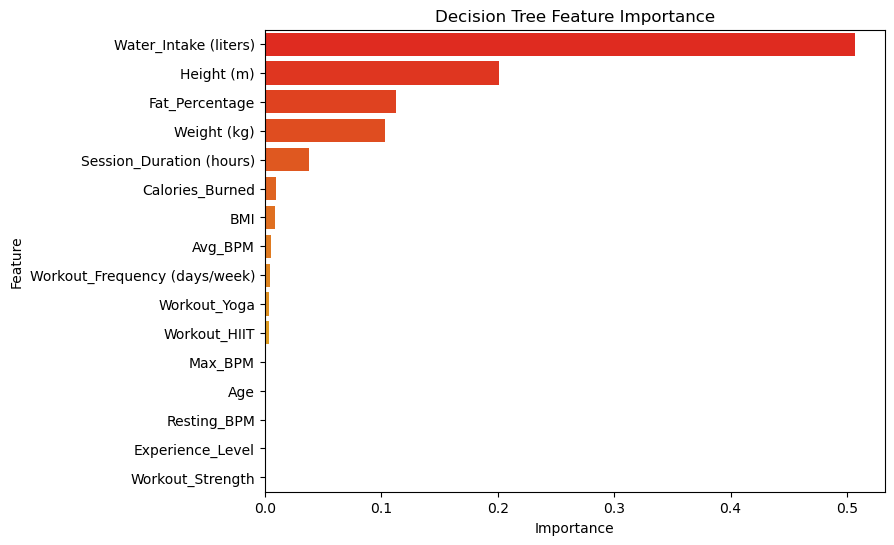

In [16]:
# ============================================================
#   DECISION TREE — FULL MODEL EVALUATION SUITE
#   This cell trains the Decision Tree and evaluates it using:
#     ✔ Accuracy
#     ✔ Classification Report
#     ✔ Confusion Matrix
#     ✔ ROC Curve + AUC
#     ✔ Precision–Recall Curve
#     ✔ Feature Importance (unique to trees)
#     ✔ Overfitting check (train vs test accuracy)
#   Every section includes comments explaining what to look for.
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
import pandas as pd

# ------------------------------------------------------------
# 1. Train the Decision Tree model
# ------------------------------------------------------------
# Trees do NOT require scaling.
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Predictions
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]  # needed for ROC/PR curves


# ------------------------------------------------------------
# 2. Accuracy Score (Test Set)
# ------------------------------------------------------------
# Accuracy = proportion of correct predictions.
# Trees often overfit, so accuracy alone is not enough.
test_accuracy = accuracy_score(y_test, y_pred_tree)
print(f"Test Accuracy: {test_accuracy:.4f}")


# ------------------------------------------------------------
# 3. Overfitting Check — Train Accuracy vs Test Accuracy
# ------------------------------------------------------------
# If train accuracy is much higher than test accuracy,
# the tree is memorising the training data (overfitting).
train_accuracy = accuracy_score(y_train, tree.predict(X_train))
print(f"Train Accuracy: {train_accuracy:.4f}")
print("If Train >> Test, the model is overfitting.\n")


# ------------------------------------------------------------
# 4. Classification Report
# ------------------------------------------------------------
# Shows precision, recall, and F1-score for each class.
# Look for balanced values across both classes.
print("Classification Report:")
print(classification_report(y_test, y_pred_tree))


# ------------------------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------------------------
# Shows EXACTLY where the model is making mistakes.
# Diagonal = correct predictions.
# Off-diagonal = errors.
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ------------------------------------------------------------
# 6. ROC Curve + AUC Score
# ------------------------------------------------------------
# ROC curve shows how well the model separates the two classes.
# AUC close to 1.0 = excellent.
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.title("Decision Tree ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 7. Precision–Recall Curve
# ------------------------------------------------------------
# Useful when one class is less common.
# Look for curves that stay high (good precision)
# and far right (good recall).
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_tree)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("Decision Tree Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


# ------------------------------------------------------------
# 8. Feature Importance (unique to Decision Trees)
# ------------------------------------------------------------
# Shows which features the tree used most for splitting.
# Higher importance = more influence on predictions.
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(8,6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='autumn')
plt.title("Decision Tree Feature Importance")
plt.show()
